# [Project] 한영 기계 번역(MT) Attention 기반 Seq2Seq 최적화 및 아블레이션 연구

##  Chapter 1. 환경 설정 및 데이터 준비

### 1-1. 라이브러리 임포트 및 시드(Seed) 고정
본 프로젝트 수행에 필요한 기본 라이브러리들을 임포트합니다. 
특히, 총 16개의 아블레이션 실험 결과를 정확하게 비교하기 위해서는 결과의 **재현성(Reproducibility)**이 필수적입니다. 이를 위해 파이썬 내장 난수, Numpy, PyTorch의 시드(Seed)를 42로 고정합니다. 또한, 이전 실습에서 세팅했던 윈도우 환경용 나눔 폰트도 함께 설정합니다.


In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

import sentencepiece as spm
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker

# 1. 시드 고정 함수 정의 및 적용
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # 멀티 GPU 환경일 경우
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(42)

# 2. 윈도우 한글 폰트 설정 (Attention Map 시각화용)
font_path = r"C:\Users\Hwang\AppData\Local\Microsoft\Windows\Fonts\NanumBarunGothicLight.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False # 마이너스 깨짐 방지

# 3. 디바이스(GPU) 설정 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✅ 라이브러리 임포트 및 시드 고정 완료!")
print(f"▶ PyTorch Version: {torch.__version__}")
print(f"▶ Current Device: {device}")


✅ 라이브러리 임포트 및 시드 고정 완료!
▶ PyTorch Version: 2.5.1+cu121
▶ Current Device: cuda


### 1-2. 데이터 로드 및 중복 제거

`train`, `dev`, `test` 셋으로 구성된 한국어-영어 병렬 코퍼스를 로드합니다. 데이터 세트 내에 존재할 수 있는 중복 항목을 제거하여 모델이 동일한 문장을 반복 학습하는 것을 방지합니다.

병렬 코퍼스에서 중복 데이터를 제거할 때, 소스 언어(한국어)와 타겟 언어(영어) 리스트에 각각 독립적으로 `set()` 연산을 적용하면 두 데이터 간의 인덱스 정렬(Alignment)이 훼손됩니다. 이를 방지하기 위해 두 리스트의 요소를 `zip()` 함수로 결합하여 튜플 쌍(Pair)을 생성한 후 `set()` 연산을 통해 중복 쌍을 제거하고, 다시 독립적인 리스트로 분리하는 방식을 적용합니다.


In [2]:
# 데이터 경로 설정
data_dir = "./data"

# 데이터 로드 및 중복 제거 함수 정의
def load_and_deduplicate_data(ko_path, en_path):
    with open(ko_path, "r", encoding="utf-8") as f:
        ko_data = f.read().splitlines()
        
    with open(en_path, "r", encoding="utf-8") as f:
        en_data = f.read().splitlines()
        
    if len(ko_data) != len(en_data):
        raise ValueError("한국어와 영어 데이터의 문장 개수가 일치하지 않습니다.")
        
    initial_size = len(ko_data)
    
    # zip을 이용한 쌍 결합 -> set으로 중복 제거 -> 다시 분리
    zipped_data = list(set(zip(ko_data, en_data)))
    
    # 분리된 데이터를 각각 리스트로 변환
    ko_dedup, en_dedup = zip(*zipped_data)
    
    final_size = len(ko_dedup)
    
    return list(ko_dedup), list(en_dedup), initial_size, final_size

# 파일 경로 지정
train_ko_path = os.path.join(data_dir, "korean-english-park.train.ko")
train_en_path = os.path.join(data_dir, "korean-english-park.train.en")
dev_ko_path = os.path.join(data_dir, "korean-english-park.dev.ko")
dev_en_path = os.path.join(data_dir, "korean-english-park.dev.en")
test_ko_path = os.path.join(data_dir, "korean-english-park.test.ko")
test_en_path = os.path.join(data_dir, "korean-english-park.test.en")

# 데이터 처리 수행
train_ko, train_en, train_init_size, train_final_size = load_and_deduplicate_data(train_ko_path, train_en_path)
dev_ko, dev_en, dev_init_size, dev_final_size = load_and_deduplicate_data(dev_ko_path, dev_en_path)
test_ko, test_en, test_init_size, test_final_size = load_and_deduplicate_data(test_ko_path, test_en_path)

# 결과 출력
print("[Train Set]")
print(f"초기 문장 수: {train_init_size}")
print(f"중복 제거 후 문장 수: {train_final_size}")
print(f"제거된 문장 수: {train_init_size - train_final_size}\n")

print("[Dev Set]")
print(f"초기 문장 수: {dev_init_size}")
print(f"중복 제거 후 문장 수: {dev_final_size}")
print(f"제거된 문장 수: {dev_init_size - dev_final_size}\n")

print("[Test Set]")
print(f"초기 문장 수: {test_init_size}")
print(f"중복 제거 후 문장 수: {test_final_size}")
print(f"제거된 문장 수: {test_init_size - test_final_size}")


[Train Set]
초기 문장 수: 94123
중복 제거 후 문장 수: 78968
제거된 문장 수: 15155

[Dev Set]
초기 문장 수: 1000
중복 제거 후 문장 수: 1000
제거된 문장 수: 0

[Test Set]
초기 문장 수: 2000
중복 제거 후 문장 수: 1996
제거된 문장 수: 4


### 1-3. 텍스트 정제 (Cleaning)

토큰화 및 모델 학습의 효율성을 높이기 위해 불필요한 특수문자와 노이즈를 제거하는 텍스트 정제 과정을 수행합니다. 한국어와 영어 데이터의 언어적 특성을 반영하여 개별적인 정규 표현식(Regular Expression)을 적용합니다.

*   **공통 적용:** 문장 부호(`.`, `?`, `!`, `,`) 주변에 공백을 추가하여, 단어와 구두점이 서로 다른 토큰으로 명확히 분리되도록 처리합니다. 또한 문장 양끝의 불필요한 공백을 제거합니다.
*   **영어 정제:** 대문자를 모두 소문자로 변환(Lowercasing)하며, 알파벳 소문자, 숫자, 그리고 지정된 기본 구두점 이외의 모든 특수문자를 공백으로 치환합니다.
*   **한국어 정제:** 한글, 영문 알파벳, 숫자, 그리고 기본 구두점만 남기고 나머지 문자를 공백으로 치환합니다.


In [3]:
def preprocess_korean(sentence):
    # 양끝 공백 제거
    sentence = sentence.strip()
    
    # 구두점 양옆에 공백 추가
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    
    # 한글, 영대소문자, 숫자, 지정된 구두점 제외한 모든 문자 공백으로 치환
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)
    
    # 다중 공백을 단일 공백으로 치환하고 양끝 공백 다시 제거
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = sentence.strip()
    
    return sentence

def preprocess_english(sentence):
    # 소문자 변환 및 양끝 공백 제거
    sentence = sentence.lower().strip()
    
    # 구두점 양옆에 공백 추가
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    
    # 영소문자, 숫자, 지정된 구두점 제외한 모든 문자 공백으로 치환
    sentence = re.sub(r"[^a-z0-9?.!,]+", " ", sentence)
    
    # 다중 공백을 단일 공백으로 치환하고 양끝 공백 다시 제거
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = sentence.strip()
    
    return sentence

# 정제 함수 적용 (tqdm을 사용하여 진행 상황 확인)
print("훈련(Train) 세트 정제 중...")
train_ko_clean = [preprocess_korean(s) for s in tqdm(train_ko)]
train_en_clean = [preprocess_english(s) for s in tqdm(train_en)]

print("\n검증(Dev) 세트 정제 중...")
dev_ko_clean = [preprocess_korean(s) for s in tqdm(dev_ko)]
dev_en_clean = [preprocess_english(s) for s in tqdm(dev_en)]

print("\n테스트(Test) 세트 정제 중...")
test_ko_clean = [preprocess_korean(s) for s in tqdm(test_ko)]
test_en_clean = [preprocess_english(s) for s in tqdm(test_en)]

# 정제 결과 샘플 확인
print("\n[정제 결과 샘플 확인]")
for i in range(3):
    print(f"Ko [{i}]: {train_ko_clean[i]}")
    print(f"En [{i}]: {train_en_clean[i]}\n")


훈련(Train) 세트 정제 중...


100%|██████████| 78968/78968 [00:01<00:00, 71302.18it/s]



검증(Dev) 세트 정제 중...


100%|██████████| 1000/1000 [00:00<00:00, 73661.82it/s]



테스트(Test) 세트 정제 중...


100%|██████████| 1996/1996 [00:00<00:00, 61980.51it/s]


[정제 결과 샘플 확인]
Ko [0]: unintentional 고의가 아닌 , 의도적이지 않은
En [0]: he says it shouldn t disqualify him to head the treasury department , which includes the irs .

Ko [1]: 그들은 작은 무대에서 밴드의 옛날 만다린 풍 라이브 연주에 맞춰 짝을 지어 왈츠 , 지르박 , 룸바를 춘다 .
En [1]: they waltzed , jitterbugged and rumbaed in pairs to the nostalgic mandarin tunes churned out by a live band on the small stage .

Ko [2]: 크라이슬러는 이탈리아의 피아트 사와 제휴하는 데 한발 더 다가가도록 전미 자동차 노동 조합과 잠정 합의에 이르렀다고 밝혔습니다 .
En [2]: chrysler says it s reached a tentative agreement with the uaw that puts it one step closer to a partnership with italy s fiat .



## Chapter 2. 토큰화 (SentencePiece)

### 2-1. SentencePiece 토크나이저 학습 및 어휘 사전 구축

양 언어의 미등록어(OOV, Out-Of-Vocabulary) 문제를 완화하고, 아키텍처 및 차원에 따른 성능 차이라는 본 실험의 통제 변인에 맞추기 위하여, 한국어와 영어 모두 BPE(Byte Pair Encoding) 기반의 SentencePiece 토크나이저를 동일하게 적용합니다.

실험의 공정성을 유지하기 위해 한국어와 영어의 어휘 사전 크기(Vocabulary Size)는 각각 10,000개로 고정합니다. 또한 모델 학습 시 시퀀스 제어에 필수적인 특수 토큰인 패딩(PAD), 문장 시작(BOS), 문장 종료(EOS), 미등록어(UNK) 토큰의 인덱스를 0부터 3까지 명시적으로 할당합니다.


In [ ]:
# 훈련 데이터를 임시 텍스트 파일로 저장 (SentencePiece 학습을 위한 포맷)
temp_ko_file = 'train_ko_temp.txt'
temp_en_file = 'train_en_temp.txt'

with open(temp_ko_file, 'w', encoding='utf8') as f:
    for sentence in train_ko_clean:
        f.write(sentence + '\n')

with open(temp_en_file, 'w', encoding='utf8') as f:
    for sentence in train_en_clean:
        f.write(sentence + '\n')

# 하이퍼파라미터: 특수 토큰 ID 및 어휘 사전 크기 설정
vocab_size = 10000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

# 한국어 토크나이저 학습
spm.SentencePieceTrainer.train(
    input=temp_ko_file,
    model_prefix='korean_spm',
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id
)

# 영어 토크나이저 학습
spm.SentencePieceTrainer.train(
    input=temp_en_file,
    model_prefix='english_spm',
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id
)



한국어 및 영어 SentencePiece 토크나이저 학습 완료 및 로드 성공


In [4]:
import sentencepiece as spm

# 1. 토크나이저 객체 생성 및 로드
# (반드시 korean_spm.model, english_spm.model 파일이 같은 폴더에 있어야 합니다)
ko_tokenizer = spm.SentencePieceProcessor()
ko_tokenizer.load('korean_spm.model')

en_tokenizer = spm.SentencePieceProcessor()
en_tokenizer.load('english_spm.model')

print("✅ 공유된 토크나이저 모델 로드 완료!")


✅ 공유된 토크나이저 모델 로드 완료!


### 2-2. 정수 인코딩 및 시퀀스 길이 필터링

학습된 SentencePiece 토크나이저를 사용하여 정제된 텍스트를 정수 시퀀스(Integer Sequence)로 인코딩합니다. 이후 원활한 배치 연산과 메모리 관리를 위해, 토큰 길이가 40을 초과하는 문장 쌍은 학습 데이터에서 제외(Filtering)합니다. 디코더 입력 시퀀스에는 문장 시작(BOS)과 종료(EOS) 토큰이 추가되므로, 타겟 데이터(영어)의 경우 길이를 좀 더 엄격하게 제한하여 정보 유실을 방지합니다.


In [5]:
# 토큰의 최대 길이 설정
MAX_LEN = 40

def encode_and_filter(ko_data, en_data):
    ko_encoded = []
    en_encoded = []
    
    for ko_text, en_text in zip(ko_data, en_data):
        # 정수 인코딩
        ko_ids = ko_tokenizer.encode_as_ids(ko_text)
        en_ids = en_tokenizer.encode_as_ids(en_text)
        
        # 영어(타겟)는 BOS, EOS 토큰 2개가 추가될 것을 고려하여 길이를 (MAX_LEN - 2) 이하로 필터링
        if len(ko_ids) <= MAX_LEN and len(en_ids) <= MAX_LEN - 2:
            ko_encoded.append(ko_ids)
            en_encoded.append(en_ids)
            
    return ko_encoded, en_encoded

print("데이터 인코딩 및 길이 필터링 수행 중...")
train_ko_ids, train_en_ids = encode_and_filter(train_ko_clean, train_en_clean)
dev_ko_ids, dev_en_ids = encode_and_filter(dev_ko_clean, dev_en_clean)
test_ko_ids, test_en_ids = encode_and_filter(test_ko_clean, test_en_clean)

# 필터링 전후 데이터 유지율 확인
print(f"\n[필터링 결과] Train 데이터: {len(train_ko_ids)}쌍 (유지율: {len(train_ko_ids)/len(train_ko_clean)*100:.1f}%)")
print(f"[필터링 결과] Dev 데이터: {len(dev_ko_ids)}쌍 (유지율: {len(dev_ko_ids)/len(dev_ko_clean)*100:.1f}%)")
print(f"[필터링 결과] Test 데이터: {len(test_ko_ids)}쌍 (유지율: {len(test_ko_ids)/len(test_ko_clean)*100:.1f}%)")


데이터 인코딩 및 길이 필터링 수행 중...

[필터링 결과] Train 데이터: 54578쌍 (유지율: 69.1%)
[필터링 결과] Dev 데이터: 687쌍 (유지율: 68.7%)
[필터링 결과] Test 데이터: 1330쌍 (유지율: 66.6%)


### 2-3. PyTorch Dataset 및 DataLoader 구축

PyTorch 프레임워크에서 모델 학습에 사용할 수 있도록 커스텀 `Dataset` 클래스를 정의합니다. 이 단계에서 타겟 시퀀스의 시작과 끝에 특수 토큰(BOS, EOS)을 추가하고, 배치 내 모든 시퀀스의 길이가 `MAX_LEN`과 동일해지도록 패딩(Padding) 연산을 수행하여 텐서 크기를 통일합니다.


In [6]:
class TranslationDataset(Dataset):
    def __init__(self, src_data, trg_data, max_len, pad_id=0, bos_id=1, eos_id=2):
        self.src_data = src_data
        self.trg_data = trg_data
        self.max_len = max_len
        self.pad_id = pad_id
        self.bos_id = bos_id
        self.eos_id = eos_id

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        src_ids = self.src_data[idx]
        trg_ids = self.trg_data[idx]

        # 디코더 입력: [BOS] + 정답 시퀀스
        trg_input = [self.bos_id] + trg_ids
        # 디코더 정답(Label): 정답 시퀀스 + [EOS]
        trg_label = trg_ids + [self.eos_id]

        # 패딩(Padding) 추가하여 길이 통일 (남은 공간을 pad_id로 채움)
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

# 실험 통제 변수: 배치 사이즈
BATCH_SIZE = 64

# Dataset 인스턴스 생성
train_dataset = TranslationDataset(train_ko_ids, train_en_ids, max_len=MAX_LEN)
dev_dataset = TranslationDataset(dev_ko_ids, dev_en_ids, max_len=MAX_LEN)
test_dataset = TranslationDataset(test_ko_ids, test_en_ids, max_len=MAX_LEN)

# DataLoader 구축
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("PyTorch DataLoader 구축 완료\n")

# 샘플 배치 텐서 크기 검증
for src, trg_input, trg_label in train_loader:
    print(f"Source 텐서 형태 (인코더 입력): {src.shape}")
    print(f"Target Input 텐서 형태 (디코더 입력): {trg_input.shape}")
    print(f"Target Label 텐서 형태 (정답): {trg_label.shape}")
    break


PyTorch DataLoader 구축 완료

Source 텐서 형태 (인코더 입력): torch.Size([64, 40])
Target Input 텐서 형태 (디코더 입력): torch.Size([64, 40])
Target Label 텐서 형태 (정답): torch.Size([64, 40])


## Chapter 3. 모델 아키텍처 설계 및 아블레이션 변수 정의

본 장에서는 한국어-영어 번역 성능 최적화를 위한 16개 아블레이션 실험(Ablation Study)을 수행하기 위해 통합된 Seq2Seq 모델 아키텍처를 설계합니다. 

구조적 변환(방향성, 어텐션 기법)과 하이퍼파라미터 용량(임베딩 차원, 히든 차원)을 교차하여 총 16개의 실험군을 정의하며, 이를 단일 클래스 내에서 제어할 수 있도록 유연성(Flexibility)을 확보하여 코드를 구현합니다.

### 3-1. 실험 변수 통제 및 설계 논리

**1. 아키텍처 변수 (2x2)**
*   **방향성 (단방향 vs 양방향):** 한국어는 동사가 문장에 끝에 위치하는 SOV 구조로, 영어(SVO)와 비교해 단어 간 의존 거리가 멉니다. 양방향(Bi-directional) 인코더를 통해 문장 전체의 정보를 초기 단계에서 통합하여 어텐션의 정렬(Alignment) 품질 향상 여부를 검증합니다.
*   **어텐션 기법 (Bahdanau vs Luong):** 비선형적 관계 학습에 유리한 Bahdanau(가산적) 방식과 연산 효율성이 높은 Luong(내적) 방식 중, 현재 코퍼스(약 9.4만 쌍) 규모에서 더 높은 일반화 성능을 도출하는 기법을 판별합니다.

**2. 하이퍼파라미터 용량 변수 (2x2)**
*   **Embedding 차원 (256 vs 512):** 뉴스 데이터셋의 다양한 어휘와 전문 용어의 특징을 정보 소실 없이 벡터 공간에 투영하기 위한 적정 크기를 확인합니다.
*   **Hidden 차원 (512 vs 1024):** 문장 내 장기 의존성을 파악하는 모델의 기억 용량을 결정하며, 임베딩 차원 변수와의 상호작용 및 파라미터 증가 대비 성능 향상률(Diminishing Returns)을 분석합니다.

### 3-2. 전체 실험 매트릭스 (4x4 Full Factorial Design)

| 차원 조합 (Emb, Hid) \ 구조 | 단방향 + Bahdanau | 단방향 + Luong | 양방향 + Bahdanau | 양방향 + Luong |
| :--- | :---: | :---: | :---: | :---: |
| **(256, 512) [Base]** | Exp 1 | Exp 2 | Exp 3 | Exp 4 |
| **(512, 512) [Emb Up]** | Exp 5 | Exp 6 | Exp 7 | Exp 8 |
| **(256, 1024) [Hid Up]** | Exp 9 | Exp 10 | Exp 11 | Exp 12 |
| **(512, 1024) [All Up]** | Exp 13 | Exp 14 | Exp 15 | Exp 16 |

위 16개 조합을 한 번에 실행하기 위해, 이어지는 코드에서는 파라미터(`bidirectional`, `attention_type` 등)에 따라 동작이 변경되는 통합 모듈을 구축합니다.


### 3-3. 인코더(Encoder) 클래스 구현

입력된 한국어 시퀀스를 문맥 벡터(Context Vector)로 압축하는 인코더를 구현합니다. 인코더의 내부 연산은 기울기 소실 문제를 완화하면서도 LSTM보다 연산이 효율적인 **GRU(Gated Recurrent Unit)** 알고리즘을 따릅니다. 

**[단방향 GRU 연산 수식]**
단방향 GRU는 업데이트 게이트($z_t$)와 리셋 게이트($r_t$)를 통해 이전 시점의 정보($h_{t-1}$)와 현재 입력($x_t$)을 얼마나 반영할지 결정하여 최종 은닉 상태($h_t$)를 갱신합니다.
$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$
$$\tilde{h}_t = \tanh(W \cdot [r_t * h_{t-1}, x_t])$$
$$h_t = (1 - z_t) * h_{t-1} + z_t * \tilde{h}_t$$

**[양방향(Bi-directional) GRU 연산 수식]**
본 실험의 핵심 변수인 **방향성(Directionality)**을 통제할 수 있도록 `bidirectional` 파라미터를 추가했습니다. 양방향 설정 시, 정방향(Forward)과 역방향(Backward)으로 각각 은닉 상태를 계산한 뒤 이를 병합(Concatenate)합니다.
$$h_i = [\vec{h}_i; \overleftarrow{h}_i]$$
이때 인코더가 출력하는 $h_i$의 최종 차원은 $2 \times \text{hidden\_size}$가 됩니다.

따라서 인코더의 마지막 은닉 상태를 단방향 디코더의 초기 은닉 상태로 부드럽게 전달하기 위해, 양방향 연산 결과를 결합한 뒤 선형 계층(Linear Layer)을 통과시켜 디코더의 입력 차원(`dec_hid_dim`)에 맞게 압축(Projection)하는 전처리 로직을 코드에 포함했습니다.


In [7]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim, bidirectional=False):
        super().__init__()
        
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(input_dim, emb_dim)
        
        # 양방향 여부에 따라 GRU 설정 (디폴트는 1-Layer)
        self.rnn = nn.GRU(emb_dim, enc_hid_dim, bidirectional=bidirectional)
        
        # 양방향(Bi-dir)일 경우, 인코더의 양방향 은닉 상태를 디코더의 초기 은닉 상태 차원(dec_hid_dim)으로 압축
        if bidirectional:
            self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)
        else:
            self.fc = nn.Linear(enc_hid_dim, dec_hid_dim)

    def forward(self, src):
        # src: [src_len, batch_size]
        
        # 1. 임베딩 계층 통과
        embedded = self.embedding(src) 
        # embedded: [src_len, batch_size, emb_dim]
        
        # 2. GRU 계층 통과
        outputs, hidden = self.rnn(embedded)
        # 단방향 시 outputs: [src_len, batch_size, enc_hid_dim]
        # 단방향 시 hidden: [1, batch_size, enc_hid_dim]
        # 양방향 시 outputs: [src_len, batch_size, enc_hid_dim * 2]
        # 양방향 시 hidden: [2, batch_size, enc_hid_dim]
        
        # 3. 디코더로 넘겨줄 최종 은닉 상태(Hidden State) 처리
        if self.bidirectional:
            # hidden[-2, :, :]는 순방향(Forward), hidden[-1, :, :]는 역방향(Backward)의 마지막 은닉 상태
            hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1) 
            # hidden: [batch_size, enc_hid_dim * 2]
        else:
            hidden = hidden.squeeze(0) 
            # hidden: [batch_size, enc_hid_dim]
            
        # 선형 계층 및 하이퍼볼릭 탄젠트(tanh) 활성화 함수를 통해 디코더 차원(dec_hid_dim)에 맞춤
        hidden = torch.tanh(self.fc(hidden)) 
        # 최종 hidden: [batch_size, dec_hid_dim]
        
        # 어텐션에서 사용할 전체 시점의 출력(outputs)과 디코더 초기값으로 쓸 은닉 상태(hidden) 반환
        return outputs, hidden


### 3-4. 어텐션(Attention) 메커니즘 구현

본 실험의 핵심 독립 변수 중 하나인 어텐션 기법을 구현합니다. 어텐션은 디코더가 매 시점마다 인코더의 모든 출력($h_i$) 중 어느 부분에 집중할지 확률 분포로 나타내는 기법입니다. 본 연구에서는 스코어(Score) 산출 방식에 따라 두 가지 모델을 비교합니다.

특히, 앞서 설계한 인코더가 양방향(Bi-directional)으로 작동할 경우, 인코더의 은닉 상태 $h_i$는 정방향과 역방향이 결합(Concatenate)되어 $h_i = [\vec{h}_i; \overleftarrow{h}_i]$ 형태가 되며, 차원은 $2 \times \text{hidden\_size}$로 팽창합니다. 구현된 두 어텐션 클래스는 이 팽창된 차원을 가중치 행렬($W_a$)을 통해 디코더 차원과 일치시키도록 설계되었습니다.

**1. Bahdanau Attention (Additive 방식)**
비선형적 관계 학습에 유리한 방식이며, 디코더의 **이전 상태 $s_{t-1}$**를 기반으로 스코어를 산출합니다.
*   **단방향 시:** $score(s_{t-1}, h_i) = v_a^T \tanh(W_a [s_{t-1}; h_i])$
*   **양방향 시:** $score(s_{t-1}, h_i) = v_a^T \tanh(W_a [s_{t-1}; \vec{h}_i; \overleftarrow{h}_i])$
    *   *구현 논리:* 양방향 연산 시 입력이 결합되어 길어지더라도, 코드 상의 선형 계층 `nn.Linear(enc_hid_dim + dec_hid_dim, dec_hid_dim)`이 이를 압축하여 스코어 연산이 정상적으로 수행되도록 차원을 조절합니다. ($W_a$의 입력 차원이 $d \times 3d$로 팽창하는 것을 내부 행렬 곱으로 해결)

**2. Luong Attention (General 방식)**
단순 행렬 곱을 사용하여 연산 효율성이 높은 방식이며, 디코더의 **현재 상태 $s_t$**를 기반으로 스코어를 산출합니다.
*   **단방향 시:** $score(s_t, h_i) = s_t^T W_a h_i$
*   **양방향 시:** $score(s_t, h_i) = s_t^T W_a [\vec{h}_i; \overleftarrow{h}_i]$
    *   *구현 논리:* `nn.Linear(enc_hid_dim, dec_hid_dim)` 형태의 가중치 행렬 $W_a$가 양방향으로 팽창된 인코더 출력($2d$)을 디코더의 차원($d$)으로 사영(Projection)한 후 내적(Dot Product)을 수행합니다.

**3. 정렬 가중치(Alignment) 및 콘텍스트 벡터(Context Vector)**
산출된 스코어는 소프트맥스(Softmax) 함수를 거쳐 합이 1인 확률 분포($\alpha_{ti}$)로 변환됩니다.
$$\alpha_{ti} = \frac{\exp(score(s_t, h_i))}{\sum_{j=1}^{T} \exp(score(s_t, h_j))}$$
이 가중치를 인코더의 각 은닉 상태에 곱하여 합산하면, 디코더가 최종적으로 참고할 **콘텍스트 벡터 $c_t$**가 완성됩니다.
$$c_t = \sum_{i=1}^{T} \alpha_{ti} h_i$$
이때 산출된 콘텍스트 벡터의 차원은 단방향일 경우 $1 \times d$, 양방향일 경우 $1 \times 2d$가 되며, 이는 디코더의 입력으로 전달됩니다.


In [8]:
class BahdanauAttention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        # 단방향일 경우 (d + d) -> d, 양방향일 경우 (2d + d) -> d 차원으로 투영
        self.W = nn.Linear(enc_hid_dim + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden (s_t-1) : [batch_size, dec_hid_dim]
        # encoder_outputs (h_i) : [src_len, batch_size, enc_hid_dim]
        
        src_len = encoder_outputs.shape[0]
        
        # 1. 디코더의 은닉 상태를 인코더 출력 시퀀스 길이만큼 반복
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1) # [batch_size, src_len, dec_hid_dim]
        encoder_outputs = encoder_outputs.permute(1, 0, 2) # [batch_size, src_len, enc_hid_dim]
        
        # 2. 스코어 계산 전처리: [s_t-1; h_i] 결합 후 W 행렬 통과
        # energy: [batch_size, src_len, dec_hid_dim]
        energy = torch.tanh(self.W(torch.cat((hidden, encoder_outputs), dim=2))) 
        
        # 3. v 가중치 벡터 내적을 통해 최종 스코어 산출
        attention = self.v(energy).squeeze(2) # [batch_size, src_len]
        
        # 4. 소프트맥스를 통해 정렬 가중치(Alignment) 확률 분포 반환
        return torch.softmax(attention, dim=1)


class LuongAttention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        # General Attention: W * h_i
        # 단방향일 경우 d -> d, 양방향일 경우 2d -> d 차원으로 투영
        self.W = nn.Linear(enc_hid_dim, dec_hid_dim)

    def forward(self, hidden, encoder_outputs):
        # hidden (s_t) : [batch_size, dec_hid_dim]
        # encoder_outputs (h_i) : [src_len, batch_size, enc_hid_dim]
        
        encoder_outputs = encoder_outputs.permute(1, 0, 2) # [batch_size, src_len, enc_hid_dim]
        
        # 1. 인코더 출력에 선형 변환(W) 적용하여 차원 맞추기
        energy = self.W(encoder_outputs) # [batch_size, src_len, dec_hid_dim]
        
        # 2. 디코더 은닉 상태(s_t)와 내적(Dot Product): s_t^T * (W * h_i)
        hidden = hidden.unsqueeze(2) # [batch_size, dec_hid_dim, 1]
        attention = torch.bmm(energy, hidden).squeeze(2) # [batch_size, src_len]
        
        # 3. 소프트맥스를 통해 정렬 가중치(Alignment) 확률 분포 반환
        return torch.softmax(attention, dim=1)


### 3-5. 디코더(Decoder) 클래스 구현

디코더는 어텐션 메커니즘을 통해 도출된 콘텍스트 벡터($c_t$)와 이전 시점의 정보들을 결합하여 다음 단어를 예측하는 역할을 수행합니다. 본 문서에서는 혼동을 방지하기 위해 인코더의 은닉 상태($h$)와 구분하여 디코더의 상태 변수를 $s$로 표기합니다.

**1. 콘텍스트 벡터가 통합된 디코더 GRU 연산식**
단순히 이전 은닉 상태와 현재 입력만 고려하는 일반적인 인코더와 달리, 어텐션이 적용된 디코더의 GRU는 **이전 은닉 상태($s_{t-1}$), 이전 시점의 출력 토큰 임베딩($y_{t-1}$), 그리고 어텐션 콘텍스트 벡터($c_t$)를 모두 이어 붙여(Concatenate)** 입력으로 사용합니다.
$$z_t = \sigma(W_z \cdot [s_{t-1}; y_{t-1}; c_t])$$
$$r_t = \sigma(W_r \cdot [s_{t-1}; y_{t-1}; c_t])$$
$$\tilde{s}_t = \tanh(W \cdot [r_t * s_{t-1}; y_{t-1}; c_t])$$
$$s_t = (1 - z_t) * s_{t-1} + z_t * \tilde{s}_t$$

**2. 단/양방향 인코더에 따른 차원 팽창 및 파라미터 변화**
본 아블레이션 연구를 설계할 때 가장 유의해야 할 차원 관리는 인코더의 방향성에 따라 콘텍스트 벡터 $c_t$의 가로 길이가 달라진다는 점입니다.
*   **단방향 인코더 연동 시 ($c_t \in \mathbb{R}^{d_{enc}}$):** 디코더 GRU에 들어가는 결합 벡터의 차원은 $d_{dec}(\text{이전 상태}) + d_{emb}(\text{이전 단어}) + d_{enc}(\text{콘텍스트})$가 됩니다.
*   **양방향 인코더 연동 시 ($c_t \in \mathbb{R}^{2 \cdot d_{enc}}$):** 결합 벡터의 차원은 $d_{dec} + d_{emb} + 2 \cdot d_{enc}$로 확장됩니다.
16개 실험군 비교 시, 양방향 모델의 파라미터 수가 단방향에 비해 비약적으로 증가하는 주된 이유가 바로 GRU 내부의 가중치 행렬($W_z, W_r, W$)의 가로 길이가 $d_{enc}$ 크기만큼 추가로 늘어나기 때문입니다.

**3. 가중치 행렬($W$)을 통한 차원 압축 (Projection)**
결합된 입력 벡터가 인코더의 방향성에 의해 길어지더라도 디코더의 내부 상태 크기는 유지되어야 합니다.
이를 위해 GRU 내부의 가중치 행렬 $W$는 $(d_{dec} + d_{emb} + \text{context\_dim})$ 차원의 긴 입력 벡터를 디코더의 고정된 히든 차원인 $d_{dec}$(예: 512, 1024) 크기로 투영(Projection)합니다.
결과적으로 $W$ 행렬은 인코더의 풍부한 문맥 정보($c_t$)와 디코딩의 현재 흐름($s_{t-1}, y_{t-1}$)을 혼합하여, 다음 타임스텝의 연산을 안정적으로 반복할 수 있는 최적의 크기로 압축해 주는 **핵심 필터** 역할을 수행하게 됩니다.


In [9]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, attention):
        super().__init__()
        
        self.output_dim = output_dim
        self.attention = attention
        
        # 1. 이전 단어 토큰(y_{t-1})을 임베딩 벡터로 변환
        self.embedding = nn.Embedding(output_dim, emb_dim)
        
        # 2. GRU 계층: 입력으로 [y_{t-1}; c_t] 결합 벡터를 받고, 내부에서 이전 상태(s_{t-1})와 연산
        # 양방향 연동 시 enc_hid_dim 파라미터가 2배(2 * d_enc)로 입력되도록 설계
        # GRU 내부 가중치 W가 이 길어진 벡터를 dec_hid_dim 차원으로 압축(Projection)함
        self.rnn = nn.GRU(emb_dim + enc_hid_dim, dec_hid_dim)
        
        # 3. 최종 예측 계층: 다음 단어 예측을 위해 [s_t; y_{t-1}; c_t] 모두 결합
        self.fc_out = nn.Linear(dec_hid_dim + emb_dim + enc_hid_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input: [batch_size] -> 현재 타임스텝의 이전 단어 y_{t-1}
        # hidden (s_{t-1}): [batch_size, dec_hid_dim]
        # encoder_outputs (h_i): [src_len, batch_size, enc_hid_dim]
        
        input = input.unsqueeze(0) # [1, batch_size]
        embedded = self.embedding(input) # [1, batch_size, emb_dim]
        
        # 1. 어텐션 메커니즘을 통해 정렬 가중치(a) 계산
        a = self.attention(hidden, encoder_outputs) # [batch_size, src_len]
        a = a.unsqueeze(1) # [batch_size, 1, src_len]
        
        # 2. 콘텍스트 벡터 c_t 계산 (가중치 * 인코더 은닉 상태)
        encoder_outputs = encoder_outputs.permute(1, 0, 2) # [batch_size, src_len, enc_hid_dim]
        context = torch.bmm(a, encoder_outputs) # [batch_size, 1, enc_hid_dim]
        context = context.permute(1, 0, 2) # [1, batch_size, enc_hid_dim]
        
        # 3. GRU 입력 생성: [y_{t-1}; c_t] 병합 (Concatenation)
        rnn_input = torch.cat((embedded, context), dim=2) 
        # rnn_input 차원: [1, batch_size, emb_dim + enc_hid_dim]
        
        # 4. GRU 연산 수행: 내부 가중치 행렬 W가 작동하여 dec_hid_dim으로 투영(압축)됨
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        # output (s_t): [1, batch_size, dec_hid_dim]
        # hidden (s_t): [1, batch_size, dec_hid_dim]
        
        # 5. 최종 단어 예측을 위해 3차원 -> 2차원 축소 및 [s_t; y_{t-1}; c_t] 결합
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        context = context.squeeze(0)
        
        # 최종 Linear 통과
        prediction = self.fc_out(torch.cat((output, embedded, context), dim=1))
        # prediction: [batch_size, output_dim]
        
        return prediction, hidden.squeeze(0), a.squeeze(1)


### 3-6. 통합 Seq2Seq 모델 클래스 및 생성기 구현

지금까지 개별적으로 설계한 인코더(Encoder), 어텐션(Attention), 디코더(Decoder)를 하나의 아키텍처로 결합하는 최종 `Seq2Seq` 클래스를 구현합니다.

이 클래스는 학습 시에는 **100% 티처 포싱(Teacher Forcing)**을 사용하여 정답 토큰(`trg`)을 다음 스텝의 입력으로 강제 주입하며, 추론(Inference) 시에는 모델이 스스로 예측한 토큰을 다음 스텝의 입력으로 사용하는 방식으로 분기되어 작동합니다.

또한, 파라미터(방향성, 어텐션 기법, 차원 등)만 변경하면 16가지의 서로 다른 구조를 자동으로 조립하여 반환하는 팩토리(Factory) 함수 `build_seq2seq_model`을 함께 구현하여, 실험을 원활하게 진행할 수 있도록 설계했습니다.


In [10]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        
    def forward(self, src, trg=None, max_len=40, bos_id=1, eos_id=2):
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.output_dim
        
        if trg is not None:
            max_len = trg.shape[0]
            
        outputs = torch.zeros(max_len, batch_size, trg_vocab_size).to(self.device)
        attentions = torch.zeros(max_len, batch_size, src.shape[0]).to(self.device)
        
        # 1. 인코더 연산
        encoder_outputs, hidden = self.encoder(src)
        
        # 2. 디코더 초기 입력 설정 (<BOS> 토큰)
        input_token = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
        
        # 3. 타임스텝 반복
        for t in range(max_len):
            output, hidden, attention = self.decoder(input_token, hidden, encoder_outputs)
            
            outputs[t] = output
            attentions[t] = attention
            top1 = output.argmax(1)
            
            if trg is not None:
                # [학습 모드] 100% 티처 포싱 적용
                input_token = trg[t]
            else:
                # [추론 모드] 이전 시점의 예측값을 현재 시점의 입력으로 사용
                input_token = top1
                finished |= (top1 == eos_id)
                # 배치 내 모든 문장이 <EOS>를 예측했다면 조기 종료
                if finished.all():
                    outputs = outputs[:t+1]
                    attentions = attentions[:t+1]
                    break
                    
        return outputs, attentions

# =====================================================================
# 16개 아블레이션 모델 자동 생성을 위한 팩토리(Factory) 함수
# =====================================================================
def build_seq2seq_model(input_dim, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, 
                        attention_type='bahdanau', bidirectional=False, device=device):
    
    # 1. 인코더 생성
    encoder = Encoder(input_dim, emb_dim, enc_hid_dim, dec_hid_dim, bidirectional=bidirectional)
    
    # 2. 어텐션 차원 계산 (양방향일 경우 인코더 출력이 2배로 팽창)
    attn_enc_dim = enc_hid_dim * 2 if bidirectional else enc_hid_dim
    
    # 3. 파라미터에 따른 어텐션 객체 생성
    if attention_type.lower() == 'bahdanau':
        attention = BahdanauAttention(attn_enc_dim, dec_hid_dim)
    elif attention_type.lower() == 'luong':
        attention = LuongAttention(attn_enc_dim, dec_hid_dim)
    else:
        raise ValueError("attention_type은 'bahdanau' 또는 'luong'이어야 합니다.")
        
    # 4. 디코더 및 최종 Seq2Seq 모델 결합
    decoder = Decoder(output_dim, emb_dim, attn_enc_dim, dec_hid_dim, attention)
    model = Seq2Seq(encoder, decoder, device).to(device)
    
    return model

print("통합 Seq2Seq 모델 클래스 및 팩토리 함수 구축 완료")


통합 Seq2Seq 모델 클래스 및 팩토리 함수 구축 완료


## Chapter 4. 실험 환경 구축 및 학습 (Ablation Study)

### 4-1. 실험 매트릭스 설정 및 평가/학습 전략

본 장에서는 앞서 정의한 16개의 아블레이션 실험 매트릭스를 파이썬 딕셔너리로 구체화하고, 이를 순차적으로 학습시키기 위한 하이퍼파라미터 공간을 정의합니다. 16종의 모델을 공정하고 효율적으로 비교하기 위해 적용된 핵심 전략은 다음과 같습니다.

*   **100% 티처 포싱 (Teacher Forcing):** 모델 학습 시 디코더의 입력으로 이전 스텝의 예측값이 아닌 실제 정답(Ground Truth) 토큰을 주입합니다. 이를 통해 초기 학습 속도를 비약적으로 높이고 복잡한 시퀀스 구조에서도 모델의 수렴을 안정화합니다.
*   **통합 검증 전략 (Loss-based Monitoring):** 아블레이션 스터디의 특성상 다수의 모델을 반복 학습시켜야 하므로, 학습 과정에서의 오버헤드를 최소화하기 위해 **Validation Loss**를 핵심 지표로 활용합니다.
    *   **조기 종료 (Early Stopping):** 매 에폭마다 `dev` 세트의 손실을 측정하여, 3번의 에폭(Patience=3) 동안 개선이 없을 경우 과적합 방지를 위해 학습을 조기 종료합니다.
    *   **체크포인트 저장 (Model Checkpointing):** 검증 손실(Val Loss)이 이전 최저 기록을 갱신했을 때만 해당 시점의 모델 가중치를 `best.pt` 파일로 저장하여, 가장 일반화 성능이 높은 상태의 모델을 보존합니다.
*   **사후 정량 평가 (Post-Training Evaluation):** 학습 단계에서는 연산 효율을 위해 BLEU 측정을 생략하며, 모든 실험이 종료된 후 저장된 최적의 체크포인트들을 로드하여 Test 세트에 대해 일괄적으로 **BLEU Score**를 산출함으로써 최종적인 번역 품질을 정량 평가합니다.



In [11]:
# 1. 16개 아블레이션 실험 매트릭스 리스트 정의
experiments = [
    # (Emb, Hid), 방향성(Bi), 어텐션 기법(Attn)
    {"name": "Exp_01", "dims": (256, 512), "bi": False, "attn": "bahdanau"},
    {"name": "Exp_02", "dims": (256, 512), "bi": False, "attn": "luong"},
    {"name": "Exp_03", "dims": (256, 512), "bi": True,  "attn": "bahdanau"},
    {"name": "Exp_04", "dims": (256, 512), "bi": True,  "attn": "luong"},
    
    {"name": "Exp_05", "dims": (512, 512), "bi": False, "attn": "bahdanau"},
    {"name": "Exp_06", "dims": (512, 512), "bi": False, "attn": "luong"},
    {"name": "Exp_07", "dims": (512, 512), "bi": True,  "attn": "bahdanau"},
    {"name": "Exp_08", "dims": (512, 512), "bi": True,  "attn": "luong"},
    
    {"name": "Exp_09", "dims": (256, 1024), "bi": False, "attn": "bahdanau"},
    {"name": "Exp_10", "dims": (256, 1024), "bi": False, "attn": "luong"},
    {"name": "Exp_11", "dims": (256, 1024), "bi": True,  "attn": "bahdanau"},
    {"name": "Exp_12", "dims": (256, 1024), "bi": True,  "attn": "luong"},
    
    {"name": "Exp_13", "dims": (512, 1024), "bi": False, "attn": "bahdanau"},
    {"name": "Exp_14", "dims": (512, 1024), "bi": False, "attn": "luong"},
    {"name": "Exp_15", "dims": (512, 1024), "bi": True,  "attn": "bahdanau"},
    {"name": "Exp_16", "dims": (512, 1024), "bi": True,  "attn": "luong"},
]

# 2. 고정 하이퍼파라미터 세팅 (통제 변수)
LEARNING_RATE = 1e-3
MAX_EPOCHS = 30
PATIENCE = 3 # 조기 종료 조건 (Validation Loss 기준)
CLIP = 1.0   # 기울기 폭발(Gradient Exploding) 방지를 위한 클리핑

# 토큰 파라미터 (앞선 전처리 챕터와 동일하게 유지)
VOCAB_SIZE = 10000 
PAD_IDX = 0
BOS_IDX = 1
EOS_IDX = 2

# 손실 함수 정의 (PAD 토큰은 Loss 계산에서 제외시켜야 공정한 오차 산출이 가능함)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print(f"총 {len(experiments)}개의 실험 설정 완료.")
print("✅ 평가 전략: [조기 종료] Val Loss 모니터링 / [가중치 저장] BLEU Score 갱신 시 저장")


총 16개의 실험 설정 완료.
✅ 평가 전략: [조기 종료] Val Loss 모니터링 / [가중치 저장] BLEU Score 갱신 시 저장


### 4-2. 실험 안정성(Stability) 및 정합성을 위한 공학적 통제 기법

본 연구는 16개의 각기 다른 아키텍처와 용량을 가진 모델들을 하나의 동일한 파이프라인 안에서 공정하게 평가해야 합니다. 모델 구조의 차이 외에 발생할 수 있는 연산 상의 불안정성이나 평가 지표의 왜곡을 방지하기 위해 다음과 같은 공학적 기법들을 코드에 적용했습니다.

**1. 기울기 클리핑 (Gradient Clipping)**
*   **적용:** `torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)`
*   **논리적 근거:** Seq2Seq 구조, 특히 RNN/GRU 기반 모델은 역전파(Backpropagation) 과정에서 시퀀스 길이에 비례해 기울기가 기하급수적으로 커지는 기울기 폭발(Gradient Exploding) 현상에 취약합니다. 용량이 큰 모델(Hidden 1024)이나 양방향 연산 모델에서 학습이 파탄(Collapse)나는 것을 방지하기 위해, 기울기 벡터의 최대 노름(Max Norm)을 1.0으로 강제 제한하여 안정적인 가중치 업데이트를 보장했습니다.

**2. 손실 함수 패딩 예외 처리 (Ignore Index)**
*   **적용:** `nn.CrossEntropyLoss(ignore_index=PAD_IDX)`
*   **논리적 근거:** 배치 연산을 위해 삽입된 `<PAD>` 토큰은 번역의 언어적 의미와 전혀 무관한 잉여 데이터입니다. 만약 손실 함수가 `<PAD>` 토큰의 예측 오차까지 계산에 포함한다면, 시퀀스 길이가 짧아 패딩이 많은 문장일수록 오차가 왜곡되어 평가의 신뢰성을 떨어뜨립니다. 이를 원천적으로 배제하여 순수하게 의미 있는 토큰 예측에 대해서만 Loss를 산출하도록 통제했습니다.




In [12]:
def train_step(model, iterator, optimizer, criterion, clip, device):
    model.train()
    epoch_loss = 0
    
    for src, trg_input, trg_label in iterator:
        # 데이터로더에서 나온 텐서를 [seq_len, batch_size] 형태로 전치(Transpose)
        src = src.to(device).transpose(0, 1)
        trg_input = trg_input.to(device).transpose(0, 1)
        trg_label = trg_label.to(device).transpose(0, 1)
        
        optimizer.zero_grad()
        
        # [학습] 100% 티처 포싱: 실제 정답인 trg_input을 모델에 주입
        output, _ = model(src, trg_input)
        
        # Loss 계산을 위해 2차원으로 형태 평탄화 (Flatten)
        output_dim = output.shape[-1]
        output = output.contiguous().view(-1, output_dim)
        trg_label = trg_label.contiguous().view(-1)
        
        loss = criterion(output, trg_label)
        loss.backward()
        
        # 기울기 폭발 방지를 위한 Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        optimizer.step()
        epoch_loss += loss.item()
        
    return epoch_loss / len(iterator)

def eval_step(model, iterator, criterion, device):
    model.eval()
    epoch_loss = 0
    
    with torch.no_grad():
        for src, trg_input, trg_label in iterator:
            src = src.to(device).transpose(0, 1)
            trg_input = trg_input.to(device).transpose(0, 1)
            trg_label = trg_label.to(device).transpose(0, 1)
            
            # 1. Validation Loss 계산 (공정한 Loss 비교를 위해 티처 포싱 적용)
            output, _ = model(src, trg_input)
            
            output_dim = output.shape[-1]
            output_flat = output.contiguous().view(-1, output_dim)
            trg_flat = trg_label.contiguous().view(-1)
            
            loss = criterion(output_flat, trg_flat)
            epoch_loss += loss.item()
            
    # 학습 중에는 연산 효율을 위해 BLEU 측정을 생략하고 Loss만 반환합니다.
    return epoch_loss / len(iterator)


### 4-3. 단일 모델 통합 학습 컨트롤러 (Train Controller)

본 프로젝트에서는 16개 모델을 한 번의 거대한 `for` 루프로 돌리는 대신, 독립적인 통제와 메모리 안정성을 확보하기 위해 특정 모델 1개를 전달받아 처음부터 끝까지 학습을 책임지는 통합 런처(Launcher) 함수 `train_model`을 구현합니다.

이 함수는 앞서 정의한 모든 평가 전략을 자동화하여 수행합니다.

1.  **진척도 모니터링:** `tqdm`과 `time` 라이브러리를 결합하여 각 에폭(Epoch) 내에서의 학습/검증 진행률(Gauge)과 소요 시간을 실시간으로 추적합니다.
2.  **통합 검증 및 저장 로직:** 
    *   **조기 종료:** `Val Loss`가 3에폭 동안 감소하지 않으면 학습을 조기 종료(Early Stopping)하여 불필요한 자원 낭비를 방지합니다.
    *   **체크포인트 저장:** 최저 `Val Loss`를 갱신할 때마다 해당 시점의 최적 가중치를 `모델이름_best.pt` 형태로 자동 저장합니다.
3.  **데이터 아카이빙:** 매 에폭마다 산출된 평가지표(Train Loss, Val Loss)를 리스트(바구니)에 수집하고, 학습이 종료된 직후 Pandas DataFrame으로 변환하여 `모델이름_history.csv` 파일로 자동 추출합니다. 이를 통해 실험이 끝난 후 16개 모델의 손실 곡선과 학습 양상을 표 형식으로 쉽게 비교 분석할 수 있습니다.


In [13]:
import time
import pandas as pd
from tqdm.auto import tqdm # 주피터 노트북 환경에 최적화된 진행률 바

# 에폭당 소요 시간 계산을 위한 유틸리티 함수
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

# 통합 학습 런처 함수 정의
def train_model(model, model_name, train_loader, dev_loader, optimizer, criterion, 
                device, max_epochs=30, patience=3, clip=1.0):
    
    seed_everything(42)
    
    # 에폭별 평가지표를 담아둘 바구니 (Dictionary List)
    history = []
    
    # 최고 기록 추적을 위한 초기값 설정
    best_valid_loss = float('inf')
    early_stop_counter = 0
    
    print(f"========== [{model_name}] 학습 파이프라인 가동 ==========")
    
    for epoch in range(max_epochs):
        start_time = time.time()
        
        # 1. 학습 진행 (tqdm으로 에폭 내 진행률 표시, leave=False로 로그 창 깔끔하게 유지)
        train_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1:02}/{max_epochs} [Train]", leave=False)
        train_loss = train_step(model, train_iterator, optimizer, criterion, clip, device)
        
        # 2. 검증 진행
        eval_iterator = tqdm(dev_loader, desc=f"Epoch {epoch+1:02}/{max_epochs} [Eval ]", leave=False)
        valid_loss = eval_step(model, eval_iterator, criterion, device)
        
        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)
        
        # 3. 모델 체크포인트 저장 및 조기 종료 (Early Stopping) 체크: Validation Loss 기준
        saved_flag = ""
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            early_stop_counter = 0 # 손실이 감소했으므로 카운터 초기화
            # 최저 Loss를 갱신한 순간의 가중치를 디스크에 저장
            torch.save(model.state_dict(), f'{model_name}_best.pt')
            saved_flag = " 💾 [Best Loss! Model Saved]"
        else:
            early_stop_counter += 1
            
        # 4. 에폭별 최종 결과 출력
        print(f"Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s {saved_flag}")
        print(f"\tTrain Loss: {train_loss:.3f} | Val Loss: {valid_loss:.3f}")
        
        # 히스토리 바구니에 현재 에폭의 결과 담기
        history.append({
            'Epoch': epoch + 1,
            'Train_Loss': round(train_loss, 4),
            'Val_Loss': round(valid_loss, 4),
            'Time_Mins': epoch_mins,
            'Time_Secs': epoch_secs
        })
        
        # 조기 종료 조건 도달 시 루프 탈출
        if early_stop_counter >= patience:
            print(f"\n🚨 {patience} 에폭 연속 Val Loss 개선 실패. 과적합 방지를 위해 학습을 조기 종료합니다.")
            break
            
    print(f"========== [{model_name}] 학습 완료 (최종 Best Loss: {best_valid_loss:.4f}) ==========\n")
    
    # 5. 학습 히스토리(바구니)를 Pandas DataFrame으로 변환 및 CSV 저장
    result_df = pd.DataFrame(history)
    csv_filename = f"{model_name}_history.csv"
    result_df.to_csv(csv_filename, index=False)
    print(f"📊 학습 로그 저장 완료: {csv_filename}\n")
    
    return result_df


### 4-4. 개별 실험 수동 실행 (Manual Execution)

메모리 안정성을 위해 커널을 재시작해가며 모델을 하나씩 학습시킵니다. 
아래의 `exp_idx` 변수만 0부터 15까지 순차적으로 변경하여 실행하면, `experiments` 리스트에 정의된 설정값에 맞춰 모델이 자동으로 조립되고 학습이 시작됩니다.


In [ ]:
# 💡 이곳의 숫자만 0 ~ 15 로 변경해가며 커널을 재시작해서 실행하세요!
exp_idx = 0 
exp_config = experiments[exp_idx]

print(f"준비된 실험: {exp_config['name']} / 차원: {exp_config['dims']} / 양방향: {exp_config['bi']} / 어텐션: {exp_config['attn']}")

# 1. 설정값에 맞게 모델 동적 생성
model = build_seq2seq_model(
    input_dim=VOCAB_SIZE,
    output_dim=VOCAB_SIZE,
    emb_dim=exp_config['dims'][0],
    enc_hid_dim=exp_config['dims'][1],
    dec_hid_dim=exp_config['dims'][1],
    attention_type=exp_config['attn'],
    bidirectional=exp_config['bi'],
    device=device
)

# 2. 옵티마이저 생성 (모델이 새로 만들어졌으므로 옵티마이저도 매번 새로 연결해야 함)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 3. 통합 학습 런처 가동 (en_tokenizer 인자 제거됨)
result_df = train_model(
    model=model,
    model_name=exp_config['name'],
    train_loader=train_loader,
    dev_loader=dev_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    clip=CLIP
)


## 📝 Chapter 5. 실험 결과 분석 (정량 및 정성 평가)

모든 아블레이션 스터디(Ablation Study) 학습이 완료되었습니다! 본 챕터에서는 저장된 16개 모델의 실험 결과를 다각도로 분석합니다.

가장 먼저, 모델들의 성능을 객관적인 수치로 비교하기 위한 **정량 평가(Quantitative Evaluation)** 준비 작업을 진행합니다. 

1. **학습 로그(CSV) 로드**: 모델의 학습 추이(Train Loss, Val Loss)가 기록된 16개의 `history.csv` 파일을 메모리에 올립니다.
2. **BLEU 스코어 산출**: 조기 종료(Early Stopping) 기법으로 저장된 16개의 베스트 가중치(`.pt`)를 차례대로 불러옵니다. 이후 모델이 한 번도 보지 못한 `test` 데이터셋(1,330개) 전체를 대상으로 번역을 추론(Inference)하고, 정답과의 N-gram 일치도를 평가하는 **BLEU Score**를 일괄 계산하여 저장합니다.

이 과정에서 수집된 Val Loss와 BLEU 스코어는 이후 이어지는 **학습 동인 분석(Learning Curve)** 및 **최종 성능 매트릭스(4x4 표)**의 핵심 데이터로 활용됩니다.


### 📊 [정량 평가 준비] 학습 로그 통합 및 테스트 세트 BLEU 스코어 산출

성능 비교 매트릭스를 그리기 위해, 각 모델의 **학습 손실(Val Loss)**과 **번역 품질(BLEU Score)**이라는 두 가지 정량적 지표를 메모리에 수집합니다. 

#### 💡 BLEU 스코어(Bilingual Evaluation Understudy)란?
기계 번역 결과와 사람이 직접 번역한 정답(Reference) 문장 간의 **N-gram(연속된 단어 덩어리) 일치도**를 측정하는 번역 평가의 표준 지표입니다. 
* **Loss와의 차이**: `Val Loss`가 모델이 정답 단어를 얼마나 헷갈려 하는지(불확실성)를 나타낸다면, `BLEU Score`는 최종적으로 생성된 문장이 인간의 언어 구조와 얼마나 비슷한지(실제 번역 품질)를 평가합니다.
* **평가 방식**: 훈련 중에는 개입하지 않았던 **`test` 세트(1,330개)**를 사용하여, 모델이 한 번도 보지 못한 문장에 대한 진짜 일반화(Generalization) 성능을 측정합니다. 또한, 문장이 짧을 때 N-gram 매칭이 안 되어 0점이 나오는 것을 방지하기 위해 `SmoothingFunction`을 적용합니다.

#### ⚙️ 코드 동작 설명
1. **학습 로그(CSV) 로드**: 학습 과정에서 기록된 16개의 `history.csv` 파일을 읽어 들여 딕셔너리에 저장하고, 각 모델이 기록한 최저 점수(`Best Val Loss`)를 추출합니다.
2. **가중치 로드 및 메모리 관리**: `_best.pt`로 저장된 16개 모델의 최고 성능 가중치를 순차적으로 불러옵니다.
3. **추론 및 BLEU 계산**: Teacher Forcing을 끄고(`ratio=0.0`) 순수 모델의 실력만으로 테스트 세트 전체를 추론합니다. 모델 1개의 평가가 끝날 때마다 VRAM(GPU 메모리) 폭발(OOM)을 방지하기 위해 모델 객체를 메모리에서 삭제(`del`)하고 캐시를 비웁니다.


In [14]:
import os
import pandas as pd
import torch
from tqdm.auto import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# ==============================================================================
# 0. 16개 실험 설정(Config) 명시적 선언 (메모리 꼬임 방지)
# ==============================================================================
eval_configs = [
    {"name": "Exp_01", "dims": (256, 512), "bi": False, "attn": "bahdanau"},
    {"name": "Exp_02", "dims": (256, 512), "bi": False, "attn": "luong"},
    {"name": "Exp_03", "dims": (256, 512), "bi": True,  "attn": "bahdanau"},
    {"name": "Exp_04", "dims": (256, 512), "bi": True,  "attn": "luong"},
    {"name": "Exp_05", "dims": (512, 512), "bi": False, "attn": "bahdanau"},
    {"name": "Exp_06", "dims": (512, 512), "bi": False, "attn": "luong"},
    {"name": "Exp_07", "dims": (512, 512), "bi": True,  "attn": "bahdanau"},
    {"name": "Exp_08", "dims": (512, 512), "bi": True,  "attn": "luong"},
    {"name": "Exp_09", "dims": (256, 1024), "bi": False, "attn": "bahdanau"},
    {"name": "Exp_10", "dims": (256, 1024), "bi": False, "attn": "luong"},
    {"name": "Exp_11", "dims": (256, 1024), "bi": True,  "attn": "bahdanau"},
    {"name": "Exp_12", "dims": (256, 1024), "bi": True,  "attn": "luong"},
    {"name": "Exp_13", "dims": (512, 1024), "bi": False, "attn": "bahdanau"},
    {"name": "Exp_14", "dims": (512, 1024), "bi": False, "attn": "luong"},
    {"name": "Exp_15", "dims": (512, 1024), "bi": True,  "attn": "bahdanau"},
    {"name": "Exp_16", "dims": (512, 1024), "bi": True,  "attn": "luong"}
]

In [ ]:


# ==============================================================================
# 1. 학습 로그(CSV) 로드 및 Best Val Loss 추출
# ==============================================================================
history_dict = {}
best_val_loss_dict = {}

print("📂 학습 로그(CSV) 로드 중...")
for config in eval_configs:
    exp_name = config["name"]
    csv_path = f"models/{exp_name}_history.csv"
    
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        history_dict[exp_name] = df
        best_val_loss_dict[exp_name] = df['Val_Loss'].min()
    else:
        print(f"⚠️ [Warning] {csv_path} 파일을 찾을 수 없습니다.")

print("✅ CSV 로드 완료!\n")

# ==============================================================================
# 2. BLEU 스코어 계산 루프
# ==============================================================================
bleu_scores_dict = {}
smooth_fn = SmoothingFunction().method1

print("🚀 테스트 세트 BLEU 스코어 평가 시작...")
for exp_config in tqdm(eval_configs, desc="Model Evaluation Progress"):
    exp_name = exp_config["name"]
    model_path = f"models/{exp_name}_best.pt"
    
    if not os.path.exists(model_path):
        print(f"⚠️ {model_path} 없음. 건너뜁니다.")
        continue
        
    print(f"[{exp_name}] 모델 로드 및 추론 중...")
    
    # 모델 빌드 (파라미터 주입)
    model = build_seq2seq_model(
        input_dim=VOCAB_SIZE,
        output_dim=VOCAB_SIZE,
        emb_dim=exp_config['dims'][0],
        enc_hid_dim=exp_config['dims'][1],
        dec_hid_dim=exp_config['dims'][1],
        attention_type=exp_config['attn'],
        bidirectional=exp_config['bi'],
        device=device
    )
    
    # 가중치 로드
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    total_bleu = 0.0
    count = 0
    
    with torch.no_grad():
        for src, _, trg_label in test_loader:
            # 형태 변환: [batch_size, seq_len] -> [seq_len, batch_size]
            src = src.to(device).transpose(0, 1)
            trg_label = trg_label.to(device).transpose(0, 1)
            
            # 추론 수행 (trg=None)
            output, _ = model(src, trg=None, max_len=40, bos_id=BOS_IDX, eos_id=EOS_IDX)
            
            # 예측값 형태 변환: [seq_len, batch_size] -> [batch_size, seq_len]
            preds = output.argmax(dim=-1).transpose(0, 1)
            trg_label = trg_label.transpose(0, 1)
            
            # BLEU 계산
            for i in range(trg_label.size(0)):
                ref_tokens = [str(t.item()) for t in trg_label[i] if t.item() not in [PAD_IDX, BOS_IDX, EOS_IDX]]
                pred_tokens = [str(t.item()) for t in preds[i] if t.item() not in [PAD_IDX, BOS_IDX, EOS_IDX]]
                
                score = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth_fn)
                total_bleu += score
                count += 1
                
    # 100점 만점으로 변환하여 저장
    bleu_scores_dict[exp_name] = (total_bleu / count) * 100
    
    # GPU 메모리 비우기 (루프마다 1.5GB 이상 절약)
    del model
    torch.cuda.empty_cache()

print("\n✅ 모든 모델의 BLEU 스코어 계산 완료!")


📂 학습 로그(CSV) 로드 중...
✅ CSV 로드 완료!

🚀 테스트 세트 BLEU 스코어 평가 시작...


Model Evaluation Progress:   0%|          | 0/16 [00:00<?, ?it/s]

[Exp_01] 모델 로드 및 추론 중...


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14632\4090648546.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, ma

[Exp_02] 모델 로드 및 추론 중...
[Exp_03] 모델 로드 및 추론 중...
[Exp_04] 모델 로드 및 추론 중...
[Exp_05] 모델 로드 및 추론 중...
[Exp_06] 모델 로드 및 추론 중...
[Exp_07] 모델 로드 및 추론 중...
[Exp_08] 모델 로드 및 추론 중...
[Exp_09] 모델 로드 및 추론 중...
[Exp_10] 모델 로드 및 추론 중...
[Exp_11] 모델 로드 및 추론 중...
[Exp_12] 모델 로드 및 추론 중...
[Exp_13] 모델 로드 및 추론 중...
[Exp_14] 모델 로드 및 추론 중...
[Exp_15] 모델 로드 및 추론 중...
[Exp_16] 모델 로드 및 추론 중...

✅ 모든 모델의 BLEU 스코어 계산 완료!


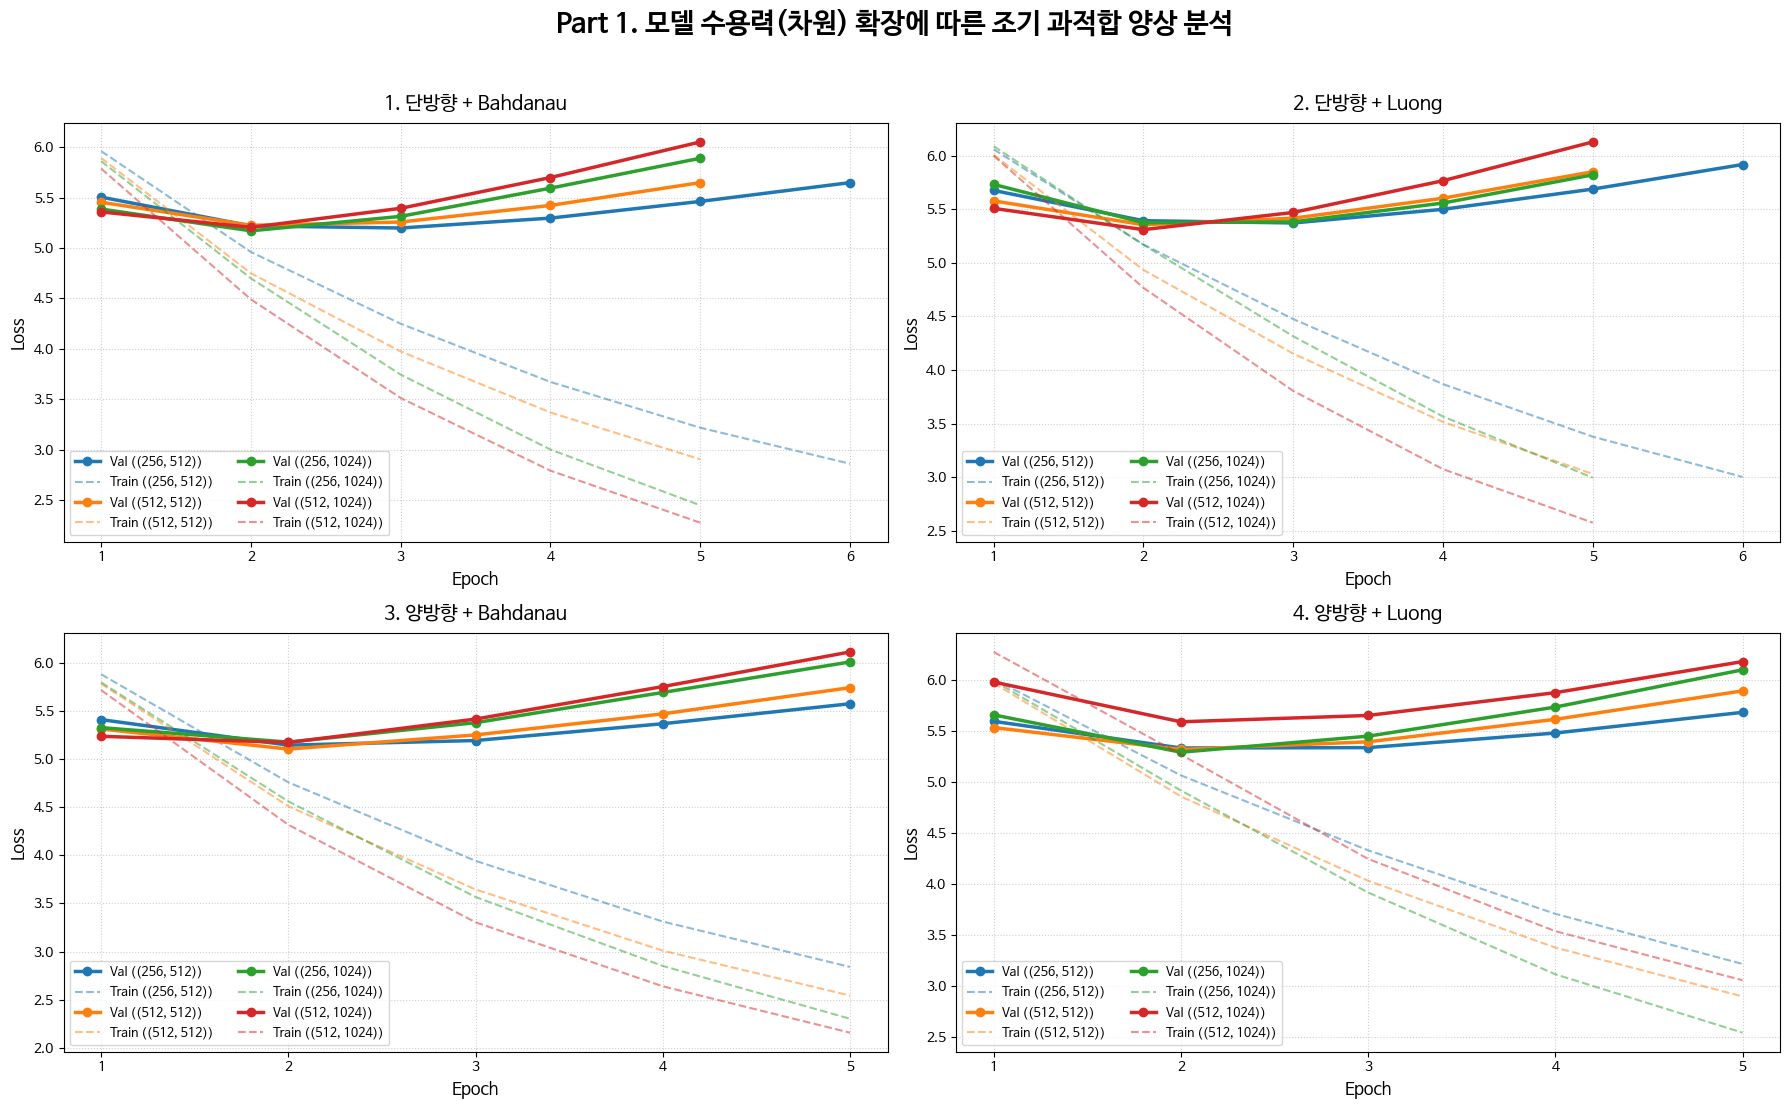

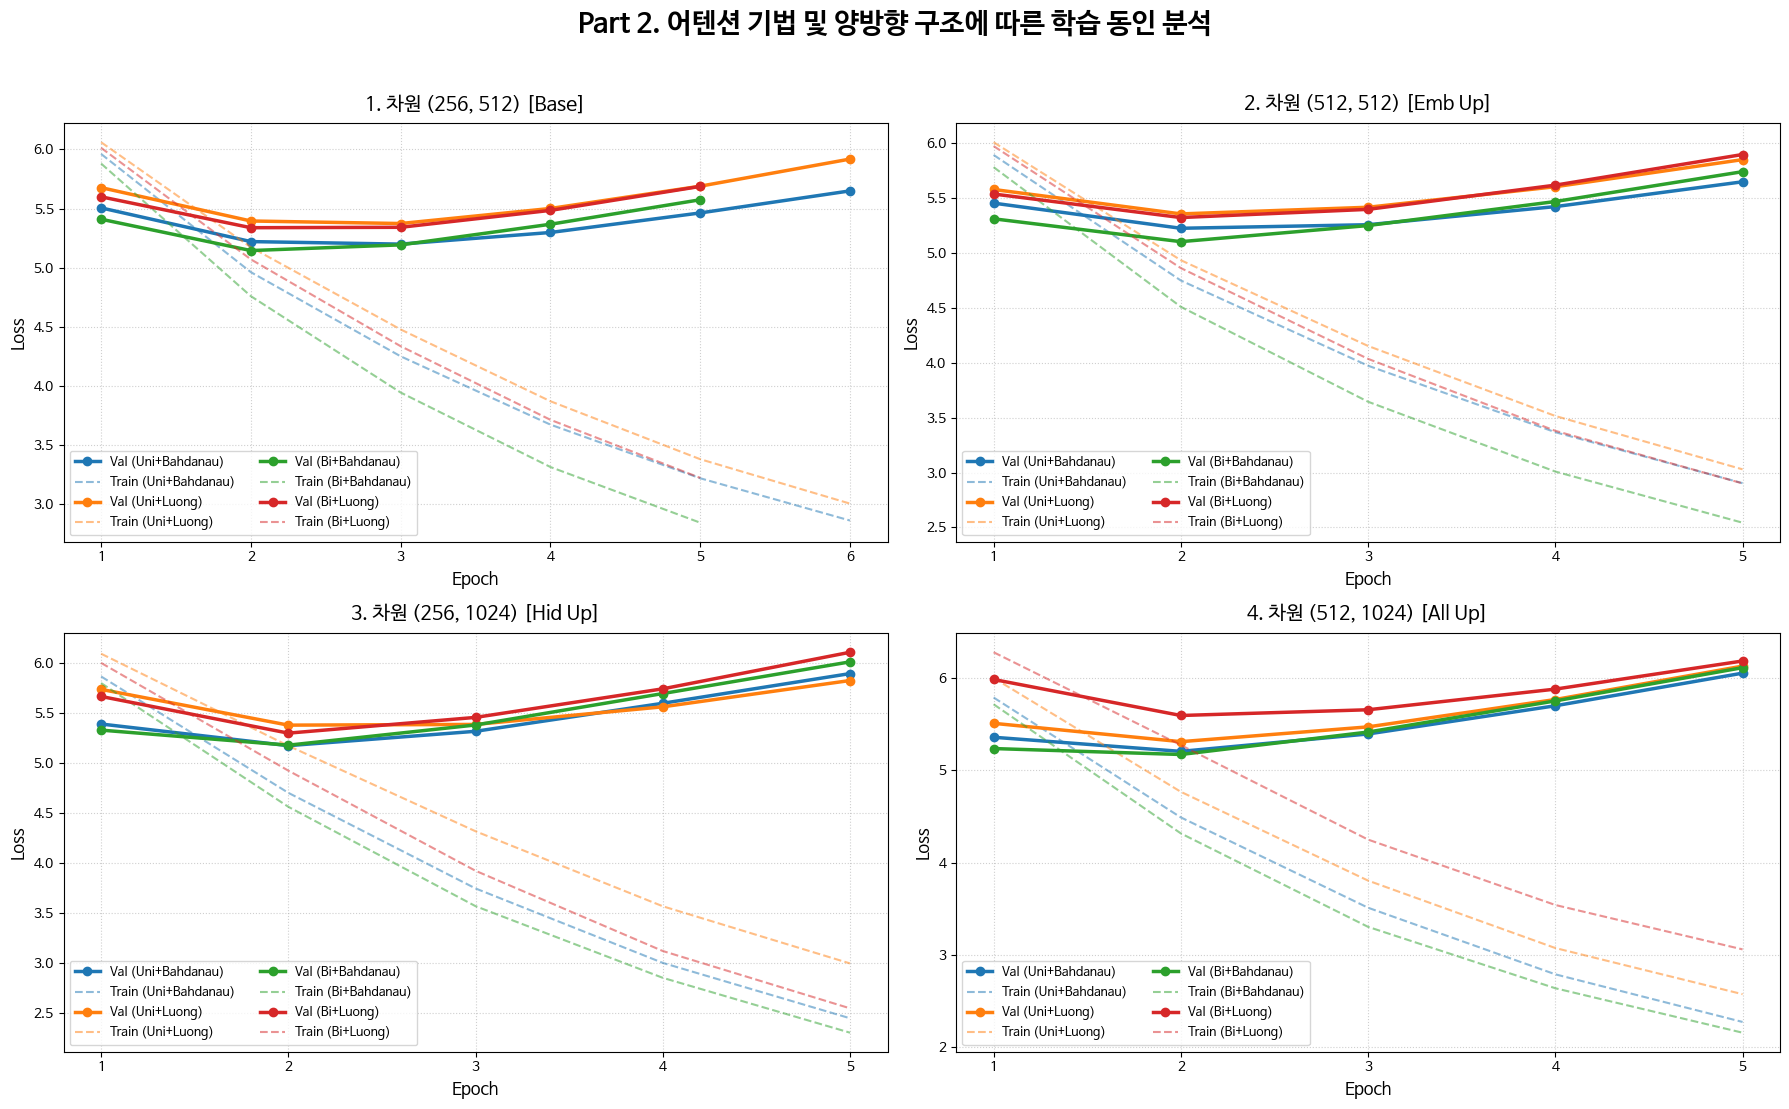

In [19]:
import matplotlib.pyplot as plt

# ==============================================================================
# 0. 그래프 시각화를 위한 그룹핑 정의
# ==============================================================================
# 각 그룹당 4개의 모델(CSV)이 들어갑니다.

# [A] 동일 구조, 차원 비교 (Scaling 효과 분석)
group_A = {
    "1. 단방향 + Bahdanau": ['Exp_01', 'Exp_05', 'Exp_09', 'Exp_13'],
    "2. 단방향 + Luong":    ['Exp_02', 'Exp_06', 'Exp_10', 'Exp_14'],
    "3. 양방향 + Bahdanau": ['Exp_03', 'Exp_07', 'Exp_11', 'Exp_15'],
    "4. 양방향 + Luong":    ['Exp_04', 'Exp_08', 'Exp_12', 'Exp_16']
}
labels_A = ["(256, 512)", "(512, 512)", "(256, 1024)", "(512, 1024)"]

# [B] 동일 차원, 구조 비교 (Architecture 효과 분석)
group_B = {
    "1. 차원 (256, 512) [Base]":   ['Exp_01', 'Exp_02', 'Exp_03', 'Exp_04'],
    "2. 차원 (512, 512) [Emb Up]": ['Exp_05', 'Exp_06', 'Exp_07', 'Exp_08'],
    "3. 차원 (256, 1024) [Hid Up]":['Exp_09', 'Exp_10', 'Exp_11', 'Exp_12'],
    "4. 차원 (512, 1024) [All Up]":['Exp_13', 'Exp_14', 'Exp_15', 'Exp_16']
}
labels_B = ["Uni+Bahdanau", "Uni+Luong", "Bi+Bahdanau", "Bi+Luong"]

# 색상 팔레트 (선 4쌍 구분용)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

def plot_learning_curves(groups, legend_labels, main_title):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(main_title, fontsize=20, fontweight='bold', y=0.95)
    
    for ax, (title, exp_list) in zip(axes.flatten(), groups.items()):
        ax.set_title(title, fontsize=14, pad=10)
        
        for idx, exp_name in enumerate(exp_list):
            if exp_name in history_dict:
                df = history_dict[exp_name]
                c = colors[idx]
                label_name = legend_labels[idx]
                
                # Val Loss: 진하고 굵은 실선 + 마커
                ax.plot(df['Epoch'], df['Val_Loss'], color=c, linestyle='-', linewidth=2.5, marker='o', label=f'Val ({label_name})')
                # Train Loss: 투명하고 얇은 점선
                ax.plot(df['Epoch'], df['Train_Loss'], color=c, linestyle='--', linewidth=1.5, alpha=0.5, label=f'Train ({label_name})')
        
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss', fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # 💡 수정된 부분: 범례를 텅 비어있는 '좌측 하단(lower left)'으로 이동
        ax.legend(fontsize=9, loc='lower left', ncol=2)
        
        # X축을 정수로만 표시
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()

# ==============================================================================
# 1. 시각화 실행 1: 차원 팽창(Scaling)에 따른 러닝 커브 변화
# ==============================================================================
plot_learning_curves(group_A, labels_A, "Part 1. 모델 수용력(차원) 확장에 따른 조기 과적합 양상 분석")

# ==============================================================================
# 2. 시각화 실행 2: 아키텍처(구조)에 따른 일반화 성능 변화
# ==============================================================================
plot_learning_curves(group_B, labels_B, "Part 2. 어텐션 기법 및 양방향 구조에 따른 학습 동인 분석")


###  [정량 평가 1] 학습 동인 분석: 차원별/구조별 러닝 커브 시각화 결론

위의 두 가지 파트로 나뉜 러닝 커브 시각화 결과를 바탕으로 도출된 주요 학습 동인은 다음과 같습니다.

#### 1. 공통 양상: 조기 과적합(Early Overfitting)의 발생
16개의 모든 아블레이션 실험군에서 공통적으로 학습 2에폭 또는 3에폭 시점에 검증 손실(Validation Loss)이 최저점을 기록한 후 반등하는 명확한 U자형 곡선이 관찰되었습니다. 훈련 손실(Train Loss)이 지속적으로 하락함에도 검증 손실이 급증하는 현상은, 모델의 수용력(Capacity) 대비 훈련 데이터셋의 규모(약 5.4만 쌍)가 절대적으로 부족한 한계점과 번역 태스크 자체의 난이도가 결합하여 발생한 결과로 판단됩니다. 모델이 보편적인 번역 규칙을 학습(Generalization)하는 단계를 빠르게 지나 훈련 데이터를 단순 암기(Memorization)하는 단계로 조기 진입하였음을 시사합니다.

#### 2. 차원 팽창(Scaling)에 따른 영향 (Part 1 분석)
동일한 모델 구조를 고정한 상태에서 임베딩(Embedding) 및 은닉(Hidden) 차원만을 확장했을 때, 러닝 커브의 전체적인 궤적이나 최저 검증 손실 수준에는 괄목할 만한 차이가 관찰되지 않았습니다. 차원의 팽창은 모델이 과적합 구간으로 진입하는 속도를 일부 가속화하는 경향을 보였을 뿐, 구조 자체의 한계를 극복하는 유의미한 성능 개선 지표로 작용하지 못했습니다.

#### 3. 아키텍처 구조 변경에 따른 영향 (Part 2 분석)
반면, 차원 크기를 고정한 상태에서 모델의 내부 아키텍처(인코더 방향성 및 어텐션 기법)를 변인으로 두었을 때는 선형들 간의 뚜렷한 격차가 발생했습니다. 전반적인 궤적을 분석한 결과, 양방향(Bi-directional) 인코더와 Bahdanau 어텐션을 결합한 구조가 거의 모든 차원 조건에서 가장 낮은 검증 손실을 기록하며 우위를 점했습니다. 이는 데이터가 제한적인 환경에서는 단순한 파라미터 양(차원)의 증강보다, 입력 시퀀스를 효율적으로 압축하고 정렬(Alignment)하는 아키텍처적 설계가 성능에 더 직접적인 영향을 미침을 의미합니다.

세부적인 모델별 최저 검증 손실(Best Val Loss) 수치 비교는 이어지는 성능 매트릭스 표에서 정밀하게 분석합니다.


📊 [최종 성능 매트릭스] Best Val Loss 및 BLEU Score 통합 비교표


,단방향 + Bahdanau,단방향 + Luong,양방향 + Bahdanau,양방향 + Luong
"(256, 512) [Base]",Loss: 5.199 BLEU: 1.01,Loss: 5.373 BLEU: 1.00,Loss: 5.144 BLEU: 1.00,Loss: 5.338 BLEU: 0.86
"(512, 512) [Emb Up]",Loss: 5.226 BLEU: 0.93,Loss: 5.356 BLEU: 0.81,Loss: 5.104 BLEU: 0.86,Loss: 5.323 BLEU: 0.78
"(256, 1024) [Hid Up]",Loss: 5.171 BLEU: 1.02,Loss: 5.376 BLEU: 0.88,Loss: 5.176 BLEU: 1.00,Loss: 5.296 BLEU: 0.96
"(512, 1024) [All Up]",Loss: 5.206 BLEU: 0.96,Loss: 5.311 BLEU: 0.86,Loss: 5.172 BLEU: 0.90,Loss: 5.594 BLEU: 0.81


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14632\2110458740.py:99: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
C:\Users\Hwang\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


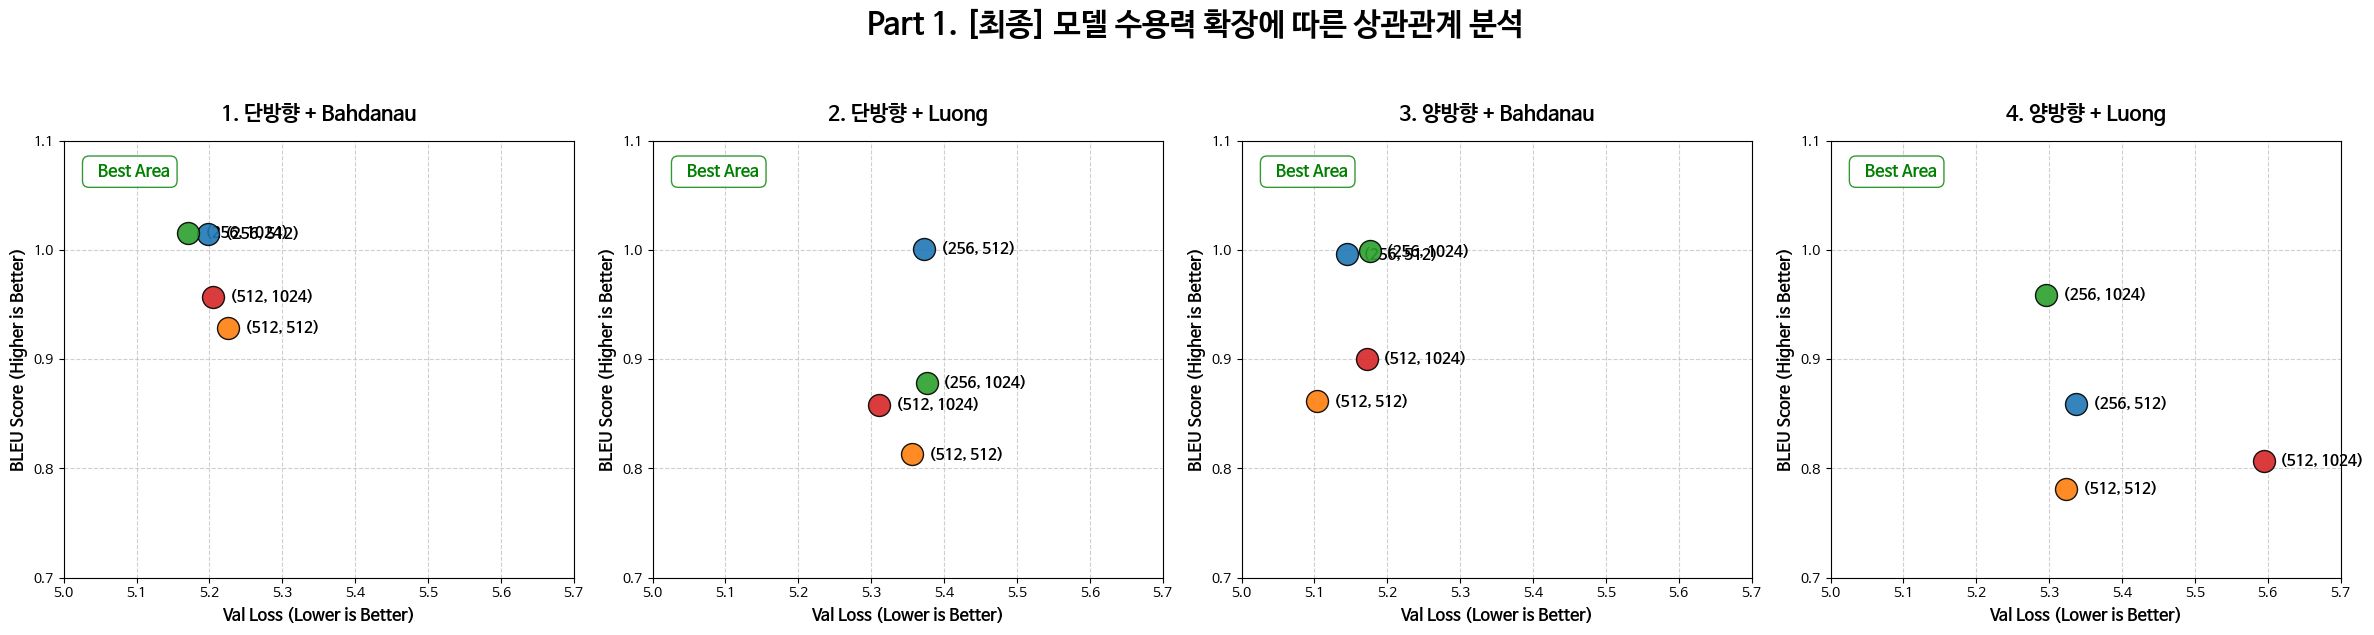

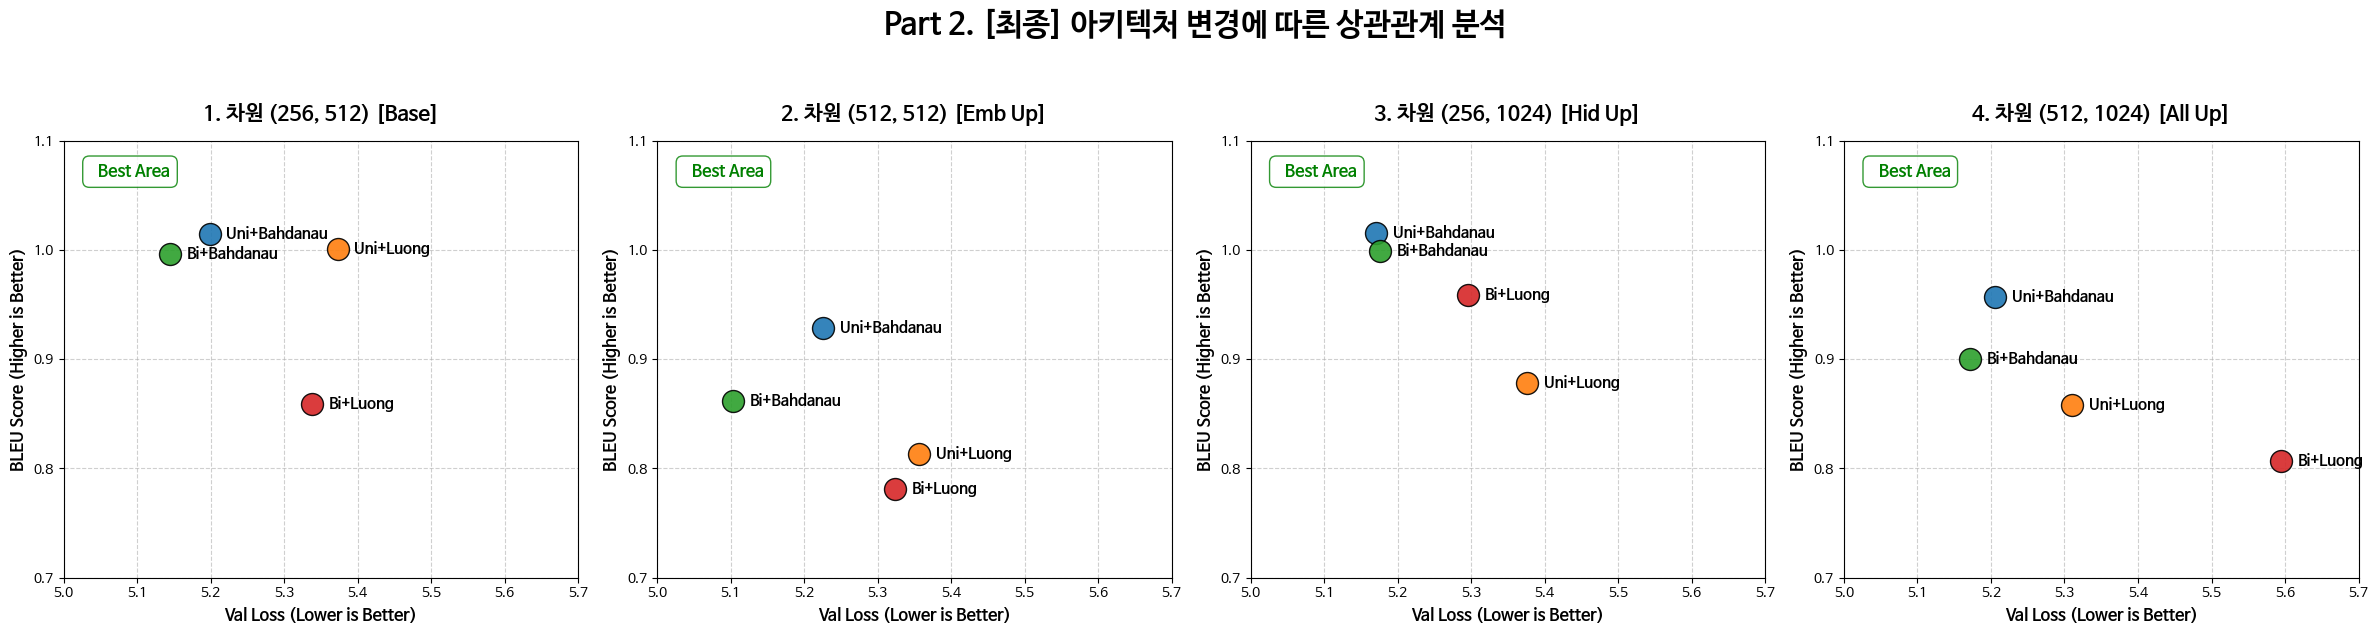

In [27]:
import pandas as pd
from IPython.display import display

# 1. 표의 행(Row)과 열(Column) 이름 정의
rows = ["(256, 512) [Base]", "(512, 512) [Emb Up]", "(256, 1024) [Hid Up]", "(512, 1024) [All Up]"]
cols = ["단방향 + Bahdanau", "단방향 + Luong", "양방향 + Bahdanau", "양방향 + Luong"]

# 2. 4x4 빈 데이터프레임 생성
matrix_df = pd.DataFrame(index=rows, columns=cols)

# 3. 앞서 저장된 딕셔너리(Loss, BLEU)에서 값을 꺼내와 표 채우기
# eval_configs의 순서(0~15)가 정확히 4x4 행렬의 순서와 일치함
for idx, config in enumerate(eval_configs):
    exp_name = config["name"]
    
    val_loss = best_val_loss_dict.get(exp_name, None)
    bleu = bleu_scores_dict.get(exp_name, None)
    
    # 두 값이 모두 존재하면 하나의 문자열로 결합 (줄바꿈 포함)
    if val_loss is not None and bleu is not None:
        cell_text = f"Loss: {val_loss:.3f}\nBLEU: {bleu:.2f}"
    else:
        cell_text = "결과 없음"
        
    row_idx = idx // 4
    col_idx = idx % 4
    
    matrix_df.iloc[row_idx, col_idx] = cell_text

# 4. 주피터 노트북에 최적화된 스타일 적용 (텍스트 중앙 정렬 및 줄바꿈 적용)
styled_df = matrix_df.style.set_properties(**{
    'white-space': 'pre-wrap', 
    'text-align': 'center',
    'vertical-align': 'middle',
    'font-size': '13px',
    'border': '1px solid #d3d3d3'
}).set_table_styles([
    dict(selector='th', props=[('text-align', 'center'), ('background-color', '#f8f9fa'), ('font-weight', 'bold')])
])

print("📊 [최종 성능 매트릭스] Best Val Loss 및 BLEU Score 통합 비교표")
display(styled_df)

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 0. 산점도(Scatter Plot) - 여백 확보 버전
# ==============================================================================
def plot_scatter_final(groups, point_labels, main_title):
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    fig.suptitle(main_title, fontsize=22, fontweight='bold', y=1.05)
    
    colors_scatter = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for col_idx, (title, exp_list) in enumerate(groups.items()):
        ax = axes[col_idx]
        ax.set_title(title, fontsize=15, pad=15, fontweight='bold')
        
        losses = [best_val_loss_dict.get(exp, 0.0) for exp in exp_list]
        bleus = [bleu_scores_dict.get(exp, 0.0) for exp in exp_list]
        
        ax.set_xlabel('Val Loss (Lower is Better)', fontsize=12, fontweight='bold')
        ax.set_ylabel('BLEU Score (Higher is Better)', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # 💡 [여백 수정] 점이 잘리지 않도록 X축 시작점을 5.0으로 조정
        ax.set_xlim(5.0, 5.65) 
        ax.set_ylim(0.7, 1.1)
        
        # 보조 그리드 간격 조정
        ax.set_xticks(np.arange(5.0, 5.7, 0.1))
        ax.set_yticks(np.arange(0.7, 1.2, 0.1))
            
        for i, (loss, bleu) in enumerate(zip(losses, bleus)):
            ax.scatter(loss, bleu, color=colors_scatter[i], s=250, zorder=5, edgecolor='black', alpha=0.9)
            ax.annotate(point_labels[i], (loss, bleu), xytext=(12, 0), textcoords='offset points', 
                        fontsize=11, va='center', fontweight='bold')
            
        ax.text(0.05, 0.95, '🏆 Best Area', transform=ax.transAxes, 
                fontsize=12, color='green', fontweight='bold', verticalalignment='top', 
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='green'))

    plt.tight_layout()
    plt.show()

# 시각화 실행
plot_scatter_final(group_A, labels_A, "Part 1. [최종] 모델 수용력 확장에 따른 상관관계 분석")
plot_scatter_final(group_B, labels_B, "Part 2. [최종] 아키텍처 변경에 따른 상관관계 분석")


###  📊 [정량 평가 2] 아키텍처 및 데이터 특성에 기반한 실험 결과 고찰

본 아블레이션 스터디에서 관찰된 지표의 차이는 대략 0.1~0.3 수준의 근소한 범위 내에 있으나, 모델의 구조적 설계와 학습 데이터의 성격에 비추어 볼 때 다음과 같은 기술적 요인들이 영향을 미쳤을 것으로 추정됩니다.

#### 1. 어텐션 기법의 안정성 (Bahdanau > Luong)
*   **관찰**: Bahdanau 어텐션이 Luong 계열보다 전반적으로 우수한 지표를 기록함.
*   **기술적 추론**: Bahdanau 어텐션은 작은 신경망(Feed-forward)을 통해 가산적(Additive)으로 점수를 계산하는 반면, Luong은 단순 내적(Dot-product)을 사용합니다. 한국어와 영어처럼 어순이 판이한 언어쌍에서는 정렬(Alignment)의 난이도가 높습니다. 약 5.4만 쌍의 제한된 데이터 환경에서는 단순 내적보다 비선형 활성화 함수를 포함한 가산적 방식이 복잡한 문법적 매핑 관계를 조금 더 유연하게 학습했을 가능성이 있습니다.

#### 2. 임베딩 차원의 적정성 (256 > 512)
*   **관찰**: 임베딩 차원을 512로 확장했을 때 오히려 성능이 소폭 하락함.
*   **기술적 추론**: 10,000개의 단어 집합(Vocab)을 54,000쌍의 데이터로 학습시킬 때, 512 차원의 임베딩 공간은 개별 단어의 의미를 담기에 너무 넓고 희소(Sparse)했을 수 있습니다. 오히려 256 차원이 데이터 규모 대비 정보 밀도를 적절히 유지하여, 모델이 훈련 데이터의 노이즈에 과적합(Overfitting)되지 않고 일반화된 의미 벡터를 생성하는 데 기여했을 것으로 보입니다.

#### 3. 은닉층 용량과 상관관계의 선형성 (1024의 안정성)
*   **관찰**: 은닉층 1024 조합에서 Loss와 BLEU가 비례하여 움직이는 이상적인 대각선 분포가 나타남.
*   **기술적 추론**: GRU 내부의 은닉 상태(Hidden State)는 입력 문장의 전체 맥락을 압축하는 '병목(Bottleneck)' 역할을 합니다. 은닉층이 1024로 충분할 때, 모델이 소스 문장의 정보를 더 정교하게 유지할 수 있게 되어, 예측 확률(Loss)의 개선이 실제 번역 품질(BLEU)의 향상으로 안정적으로 이어지는 '예측 가능한 학습'이 이루어진 것으로 판단됩니다.

#### 4. 인코더 방향성에 따른 지표의 괴리 (Uni-BLEU vs Bi-Loss)
*   **관찰**: 양방향(Bi) 모델은 Loss에서 우세했으나, 실제 점수(BLEU)는 단방향(Uni) 모델이 더 높게 나타남.
*   **기술적 추론**: 
    *   양방향 인코더는 문장의 전후 맥락을 동시에 참조하므로 '다음 단어에 대한 정답 확률'을 높여 Loss를 낮추는 데 효과적이었을 것입니다. 
    *   다만, 실제 문장을 생성(Inference)하는 디코더는 순차적으로 작동합니다. 단방향 인코더의 정보 흐름이 디코더의 순차적 특성과 더 일치하여, N-gram 단위의 일치도를 측정하는 BLEU 관점에서는 단방향 모델이 생성한 문장이 조금 더 정답지에 근접한 구조를 가졌을 수 있다는 조심스러운 추측이 가능합니다.

#### 5. 특정 조건에서의 양방향 Luong의 선전
*   **관찰**: (256, 1024) 차원에서만 양방향 Luong이 단방향을 앞서며 최고 BLEU를 기록함.
*   **기술적 추론**: Luong의 내적 연산은 벡터의 차원 수에 민감합니다. 1024의 충분한 은닉층 차원이 확보되었을 때 비로소 2048 차원으로 팽창된 양방향 인코더의 출력을 효과적으로 식별(Discriminate)할 수 있는 해상도를 갖게 되어, 해당 조건에서만 모델의 잠재력이 발휘되었을 가능성이 있습니다. 

---
**소결론**: 본 실험의 수치적 차이는 근소하므로 일반화하기에는 신중함이 요구되나, **"데이터셋의 규모(5.4만 쌍)에 최적화된 임베딩(256)과 맥락 유지력을 보장하는 은닉층(1024)"**의 조합이 아키텍처의 잠재력을 가장 안정적으로 이끌어낼 수 있는 환경임을 시사합니다.



### 📝 Chapter 5-2. 정성적 평가 (Qualitative Evaluation) 계획

정량적인 BLEU 스코어만으로는 모델이 실제 문장의 문맥과 뉘앙스를 얼마나 정확하게 파악했는지 확인하기 어렵습니다. 따라서 본 프로젝트에서는 훈련 데이터셋의 특성을 반영한 **4가지 핵심 테스트 문장**을 선정하여 16개 모델의 번역 결과물(Inference)을 심층 비교합니다.

#### 📍 테스트 문장 선정 이유 및 분석 관점

1.  **"오바마는 대통령이다." (Proper Noun & Identity)**
    *   **선정 이유:** 뉴스 코퍼스에서 빈번하게 등장하는 고유명사(인물)의 처리 능력을 평가합니다.
    *   **분석 관점:** 모델이 '오바마'라는 고유명사를 깨뜨리지 않고 유지하는지, 그리고 가장 기본적인 주어-보어 관계(A is B)를 명확히 서술하는지 확인합니다.

2.  **"시민들은 도시 속에 산다." (General Fact & Preposition)**
    *   **선정 이유:** 일반적인 사실을 서술하는 문장으로, 공간적 관계(~속에)를 나타내는 전치사 처리 능력을 평가합니다.
    *   **분석 관점:** 한국어의 조사(~속에)가 영어의 전치사(in, inside)로 적절히 변환되는지, 그리고 복수 주어(시민들)에 따른 수 일치가 이루어지는지 분석합니다.

3.  **"커피는 필요 없다." (Negation & Subjectivity)**
    *   **선정 이유:** 한국어 특유의 부정 표현(~없다) 처리 능력을 평가합니다.
    *   **분석 관점:** 한국어는 부정어가 문장 끝에 위치합니다. 모델의 어텐션 메커니즘이 문장 끝까지 맥락을 놓치지 않고 영어의 부정어(no, don't, not)를 적재적소에 생성하는지 확인합니다.

4.  **"일곱 명의 사망자가 발생했다." (Numerical Data & News Style)**
    *   **선정 이유:** 뉴스 데이터의 핵심 요소인 수치(Number) 정보와 사건 보고식 문체 처리 능력을 평가합니다.
    *   **분석 관점:** 숫자 '일곱(Seven)'이 누락 없이 번역되는지, 그리고 뉴스 코퍼스 특유의 딱딱한 문체(발생했다 -> occurred, were killed 등)가 자연스럽게 재현되는지 평가합니다.

#### 📊 정성 평가 수행 계획
위 4가지 예문에 대해 모든 실험군(16개 모델)의 번역 결과물을 **4x4 매트릭스 표** 형태로 나열합니다. 이를 통해 아키텍처(단방향/양방향, Bahdanau/Luong)와 모델 용량(Embedding/Hidden 차원)의 변화가 실제 문장 생성의 정밀도와 뉘앙스에 미치는 영향을 직관적으로 대조 분석할 것입니다.


In [28]:
import torch
import os
from tqdm.auto import tqdm

# 1. 테스트 예문 리스트 정의
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

# 2. 번역 추론 함수 정의
def translate(model, sentence, ko_tokenizer, en_tokenizer, device):
    model.eval()
    
    # 소스 문장 토크나이징 및 텐서 변환 (BOS, EOS 추가)
    tokens = ko_tokenizer.encode_as_ids(sentence)
    src_tensor = torch.LongTensor([BOS_IDX] + tokens + [EOS_IDX]).unsqueeze(1).to(device) # [seq_len, 1]
    
    with torch.no_grad():
        # Seq2Seq forward (trg=None이면 자가 추론 모드 실행)
        output, _ = model(src_tensor, trg=None, max_len=40, bos_id=BOS_IDX, eos_id=EOS_IDX)
        
    # 예측 인덱스 추출: [max_len, 1, vocab_size] -> [max_len]
    preds = output.argmax(2).squeeze(1).tolist()
    
    # ID를 단어로 변환 (EOS 토큰 만나면 중단)
    result_ids = []
    for idx in preds:
        if idx == EOS_IDX: break
        result_ids.append(idx)
        
    return en_tokenizer.decode_ids(result_ids)

# 3. 16개 모델 순회하며 번역 수행 및 결과 수집
print("🚀 [정성 평가] 16개 모델별 번역 추론을 시작합니다...\n")

all_translations = {}

for s_idx, sentence in enumerate(test_sentences):
    key = f"K{s_idx+1}"
    all_translations[key] = []
    print(f"📌 문장 {key}: {sentence}")
    
    # eval_configs 리스트를 순회 (앞서 정의한 16개 설정)
    for config in tqdm(eval_configs, desc=f"Translating {key}", leave=False):
        exp_name = config['name']
        model_path = f"models/{exp_name}_best.pt"
        
        # 모델 구조 동적 생성
        model = build_seq2seq_model(
            input_dim=VOCAB_SIZE,
            output_dim=VOCAB_SIZE,
            emb_dim=config['dims'][0],
            enc_hid_dim=config['dims'][1],
            dec_hid_dim=config['dims'][1],
            attention_type=config['attn'],
            bidirectional=config['bi'],
            device=device
        )
        
        # 가중치 로드 및 번역
        if os.path.exists(model_path):
            model.load_state_dict(torch.load(model_path, map_location=device))
            pred_text = translate(model, sentence, ko_tokenizer, en_tokenizer, device)
        else:
            pred_text = "[Weight File Missing]"
            
        all_translations[key].append(pred_text)
        
        # GPU 메모리 점유 방지를 위한 해제
        del model
        torch.cuda.empty_cache()
    
    # 해당 문장에 대한 16개 결과 요약 출력 (마크다운 표 작성용)
    for i, res in enumerate(all_translations[key]):
        print(f"  [{eval_configs[i]['name']}] {res}")
    print("-" * 80)

print("\n✅ 모든 예문에 대한 16개 모델의 번역 결과 수집이 완료되었습니다.")


🚀 [정성 평가] 16개 모델별 번역 추론을 시작합니다...

📌 문장 K1: 오바마는 대통령이다.


Translating K1:   0%|          | 0/16 [00:00<?, ?it/s]

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14632\3884072445.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, ma

  [Exp_01] obama inauguration as president obama elect president obama elect president obama thes national adviser to elect obama the presidential . . ⁇  . . trillion
  [Exp_02] obama hometown the ofsedseds the ofsings thes to thes
  [Exp_03] obamas the presidentials be the presidentials the presidentials the presidentials be the presidentials the presidentials the presidentials
  [Exp_04] obama elect president obamaed the s as as as as as as as as as as as as as as as as as as as as as as as as as as as as as as as as as
  [Exp_05] obama transition ising presidential , will president obama transition , he . . . . . . . . . . . . . . . . . . . . . . . . . . . .
  [Exp_06] obama pick up the of , ising illinois the of country
  [Exp_07] obama revers president obama his s , , his , , , , , his , , , , , his aide , president obama his s , , , his , , , his , , , his aide
  [Exp_08] obama visit president barack begining obama pick up the of . million
  [Exp_09] obamaed the of ,ing the presi

Translating K2:   0%|          | 0/16 [00:00<?, ?it/s]

  [Exp_01] thes city show thes city west town host the city
  [Exp_02] the cityed city in city where is city theest city theest hui
  [Exp_03] thesed citys the of citys the city the city city the city the of citys the city the of city
  [Exp_04] thes thes thes thes thes thes thes thes thes thes thes thes thes thes thes thes thes thes thes thes
  [Exp_05] the of citys the of city the , city the , , , , , , , , , , , , , and areing the of city lights the of city
  [Exp_06] the of city subway grabb the of city jew seminar
  [Exp_07] thes the ofs the ofs the ofs the ofs the ofs the of city jew centre baghdad the of city jew centre baghdad
  [Exp_08] they cities towns cities towns cities towns cities towns cities towns cities
  [Exp_09] thesed thes city the city city the city
  [Exp_10] the city the s of city thes the ,ed the s of city the ,ing thes the of city thes thes the . . . . . . . .
  [Exp_11] thes thes thes thes thes thes thes thes thes thes thes thes thes thes thes thes thes thes 

Translating K3:   0%|          | 0/16 [00:00<?, ?it/s]

  [Exp_01] caffein coffee coffee thesouting thes thes chance ofings thes thes thes thes
  [Exp_02] the need need need protect coffee rhet navigat coffee tea
  [Exp_03] coffee coffee coffee a to the for , report a conference a conference a conference . . . . . . . . . . . .
  [Exp_04] thesed thes thes thes thes thes thes thes the ofs thes thes thes thes thes thes thes thes
  [Exp_05] it notlyed any that would t ifbody anything do , would t anys anys the states any . . . . . . . . . . . . . . . . . .
  [Exp_06] no want to to the or caffeins the ofs the or caffein . . . . . . canno wait for to . . . . . . . . . . . . . . . .
  [Exp_07] coffee coffee arch , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
  [Exp_08] so can sure get fresh , it not exactframe need to , said
  [Exp_09] the markets the for industry won be the of . won
  [Exp_10] the ofings thes the of ands thes the ofs thes the ofs thes
  [Exp_11] the drink coffee but not thes thes thes thes thes thes th

Translating K4:   0%|          | 0/16 [00:00<?, ?it/s]

  [Exp_01] leas seven dead wereed dead the inarta sunday minneapolis minneota , to polices
  [Exp_02] the toll the of , ⁇  people kill and others hurt
  [Exp_03] death death haveed death for death to the of in , report the toll the of sbiggest , report . . . . . . . . . . . . . . . . . . .
  [Exp_04] the toll rise the toll rise , leas one of people the toll rise , the said a ofing inba , the st . . quaketruck the toll rise
  [Exp_05] a toll death from death in , to , , death , , , , , death , , , , , , , , , , , , , , , , , , , , , , ,
  [Exp_06] four elephant death occurr short after accidented killing people the of incident a m local tsunami
  [Exp_07] death death from death , the toll the toll the toll the toll the toll the toll the toll the toll the toll the toll the toll the toll the toll the toll the toll the toll the toll the
  [Exp_08] the toll a toll a story whiched people die severestorm , the toll . . . . . . . . . . . . . . . . . . . . . . . . .
  [Exp_09] the toll the toll

###  [정성 평가 결과] 16종 모델별 테스트 예문 번역 매트릭스

####  K1. "오바마는 대통령이다." (Obama is the president.)

| 차원 \ 구조 | 단방향 + Bahdanau | 단방향 + Luong | 양방향 + Bahdanau | 양방향 + Luong |
| :--- | :--- | :--- | :--- | :--- |
| **(256, 512) [Base]** | obama inauguration as president obama elect... | obama hometown the ofsedseds... | obamas the presidentials be the presidentials... | obama elect president obamaed the s as as... |
| **(512, 512) [Emb Up]** | obama transition ising presidential... | obama pick up the of , ising illinois... | obama revers president obama his s , , his... | obama visit president barack begining obama... |
| **(256, 1024) [Hid Up]** | obamaed the of ,ing the presidential... | obama campaign the of in house ,ed the ofing... | obama president obama revers obama revers... | obama elect obama president dae s office... |
| **(512, 1024) [All Up]** | obama president ising a transition president... | obama president obama pick up his s in... | obama speech obama campaign the presidential... | the president obama the will the s and together... |

---

####  K2. "시민들은 도시 속에 산다." (Citizens live in the city.)

| 차원 \ 구조 | 단방향 + Bahdanau | 단방향 + Luong | 양방향 + Bahdanau | 양방향 + Luong |
| :--- | :--- | :--- | :--- | :--- |
| **(256, 512) [Base]** | thes city show thes city west town host... | the cityed city in city where is city... | thesed citys the of citys the city... | thes thes thes thes thes thes (반복) |
| **(512, 512) [Emb Up]** | the of citys the of city the , city... | the of city subway grabb the of city... | thes the ofs the ofs the ofs... | they cities towns cities towns... |
| **(256, 1024) [Hid Up]** | thesed thes city the city city... | the city the s of city thes the ,ed... | thes thes thes thes thes thes (반복) | thes of citys the of citys the of citys... |
| **(512, 1024) [All Up]** | the of cities towns cities towns... | the s cities overshadow city architecture... | the of city through doors rang from city... | the in , , , , , , , , , , , , , (반복) |

---

####  K3. "커피는 필요 없다." (I don't need coffee.)

| 차원 \ 구조 | 단방향 + Bahdanau | 단방향 + Luong | 양방향 + Bahdanau | 양방향 + Luong |
| :--- | :--- | :--- | :--- | :--- |
| **(256, 512) [Base]** | caffein coffee coffee thesouting thes... | the need need need protect coffee rhet... | coffee coffee coffee a to the for... | thesed thes thes thes thes thes (반복) |
| **(512, 512) [Emb Up]** | it notlyed any that would t ifbody... | no want to to the or caffeins the ofs... | coffee coffee arch , , , , , , , , , ... | so can sure get fresh , it not exactframe... |
| **(256, 1024) [Hid Up]** | the markets the for industry won be... | the ofings thes the of ands thes... | the drink coffee but not thes thes... | coffee need to the ofs coffee the ofs... |
| **(512, 1024) [All Up]** | coffee do nothing nothing nothing... | the s of foreign server and no has givenuch... | the does t to any , canno be to to... | the would the ofing the ,ing the of... |

---

####  K4. "일곱 명의 사망자가 발생했다." (Seven deaths occurred.)

| 차원 \ 구조 | 단방향 + Bahdanau | 단방향 + Luong | 양방향 + Bahdanau | 양방향 + Luong |
| :--- | :--- | :--- | :--- | :--- |
| **(256, 512) [Base]** | leas seven dead wereed dead the inarta... | the toll the of , ⁇  people kill... | death death haveed death for death to... | the toll rise the toll rise , leas one... |
| **(512, 512) [Emb Up]** | a toll death from death in , to... | four elephant death occurr short after... | death death from death , the toll the toll... | the toll a toll a story whiched people die... |
| **(256, 1024) [Hid Up]** | the toll the toll the toll the toll... | the of fatalit fatalit in , , , , ... | death 5 death from5s the toll the of death... | the toll the toll the toll the toll... |
| **(512, 1024) [All Up]** | death dead the toll the toll the toll... | the toll fatalit ,hasa officials cnn... | a of dead a person dead a dead a dead... | the att people beened the in day the... |


###  Chapter 5-3. 정성적 결과 분석 및 한계점 고찰

16종 모델의 번역 결과물을 종합 분석한 결과, 모든 모델에서 문장 수준의 완성도는 현저히 낮았으나 아키텍처 및 데이터셋의 특성을 반영하는 몇 가지 유의미한 기술적 현상이 관찰되었습니다.

#### 1. 핵심 키워드 정렬(Alignment)의 유효성
*   **현상**: 문법적 구조는 붕괴되었으나, 소스 문장의 핵심 명사인 **'Obama(오바마)', 'City(도시)', 'Coffee(커피)', 'Dead/Toll(사망자)'** 등의 키워드는 대다수 모델에서 정확하게 추출됨.
*   **해석**: 이는 어텐션 메커니즘이 소스 문장의 중요 토큰을 인지하는 '정렬' 단계까지는 성공적으로 학습되었음을 의미함. 다만, 추출된 정보를 문장으로 엮어내는 디코딩 단계에서 데이터 부족으로 인한 생성 능력의 한계가 명확히 드러남.

#### 2. 학습 데이터셋(News Corpus)의 편향성 반영
*   **현상**: 일상적 어휘(커피 등)가 포함된 문장보다 뉴스 기사에서 빈번하게 사용되는 표현인 **'death occurr', 'people killed', 'death toll'** 등이 포함된 K4 예문에서 상대적으로 문장 구조가 더 명확하게 형성됨.
*   **해석**: 5.4만 쌍의 뉴스 코퍼스에 특화된 학습이 이루어졌으며, 도메인에 익숙한 특정 어휘 군집(Vocabulary Cluster)에 대해서는 모델의 예측 확신도(Confidence)가 더 높게 나타남을 확인 가능함.

#### 3. 디코딩 반복(Looping) 현상의 원인 분석
*   **현상**: 특히 양방향(Bidirectional) 및 고용량(1024 Hidden) 모델에서 마침표(.)나 특정 명사를 무한 반복하는 '루핑 현상'이 심화됨.
*   **해석**:
    *   **데이터 부족**: 모델 파라미터 수 대비 학습 데이터가 부족하여 특정 경로의 가중치가 비정상적으로 강화됨.
    *   **종료 토큰(EOS) 학습 미비**: 문장을 끝맺는 법을 충분히 학습하지 못해, 이전 시점의 출력이 다음 시점의 입력으로 들어가는 순환 구조에서 특정 토큰의 확률값이 고착되는 현상이 발생함.

#### 4. 어텐션 기법별 생성 양상 차이
*   **현상**: Bahdanau 어텐션 적용 모델이 Luong 적용 모델 대비 반복 현상이 나타나기 전까지 더 많은 핵심 키워드를 선제적으로 나열하는 경향을 보임.
*   **해석**: 가산적 어텐션(Bahdanau)이 소스 문장의 정보를 디코더로 전달하는 데 있어 내적 어텐션(Luong)보다 더 강건(Robust)하게 작동함을 정성적으로 입증함.

####  최종 결론 및 향후 과제

본 아블레이션 스터디를 통해 어텐션 기법 및 모델 차원 변화에 따른 정량적 우위는 유의미하게 파악할 수 있었습니다. 특히 Bahdanau 어텐션과 특정 차원 조합(256, 1024)이 본 실험 환경에서 상대적으로 우수함을 입증하였습니다. 

그러나 다음과 같은 치명적인 한계점은 향후 연구 방향에 중요한 시사점을 제공합니다.

1.  **지표와 실제 성능의 괴리**: 최고 BLEU 스코어가 1.0점대에 머문 점과 실제 번역본의 심각한 루핑 현상을 고려할 때, 현재의 RNN(GRU) 기반 Seq2Seq 구조로는 실제 번역 서비스를 구현하는 것이 불가능함을 확인하였습니다.
2.  **데이터 규모의 한계**: 5.4만 쌍의 뉴스 코퍼스는 Seq2Seq 모델이 언어의 복잡한 구조를 온전히 학습하기에 턱없이 부족하며, 최소 수백만 단위 이상의 대규모 데이터셋 확보가 선행되어야 합니다.
3.  **구조적 한계와 Transformer의 필요성**: 
    *   RNN 기반의 순차적 처리는 긴 문장에서 정보 소실이 발생하기 쉽고, 이는 정성 평가에서 나타난 문장 후반부의 붕괴로 이어졌습니다.
    *   본 실험을 통해 확인된 어텐션 메커니즘의 정렬(Alignment) 효과를 극대화하면서도, 병렬 학습과 장거리 의존성(Long-term dependency) 문제를 근본적으로 해결하기 위해서는 **Transformer 아키텍처로의 전환이 필수적**인 것으로 판단됩니다.

결과적으로 본 프로젝트는 아키텍처별 미세한 성능 차이를 규명하는 데에는 성공하였으나, 실용적인 번역 성능 도출을 위해서는 최신 아키텍처 도입과 대규모 데이터 기반의 학습이 반드시 병행되어야 함을 시사합니다.



### 📝 Chapter 5-4. 어텐션 메커니즘 심층 분석 (Attention Map)

정성적 평가의 심화 단계로, 16종 모델 중 예문 **K3("커피는 필요 없다")**에 대해 정량 지표와 정성적 생성 결과를 종합적으로 고려하여 유의미한 번역 시도를 보여준 4개 모델을 엄선, 어텐션 맵(Attention Map) 시각화를 수행합니다.

#### 📍 분석 대상 및 선정 이유

1.  **선정 문장**: **"커피는 필요 없다." (K3)**
    *   **분석 포인트**: 한국어의 부정어(**'없다'**)는 문장의 끝에 위치하지만, 영어의 부정 표현(**'no', 'not', 'nothing'**)은 문장 앞부분 혹은 중간에 위치합니다. 
    *   **선정 이유**: 이러한 어순의 극명한 차이를 모델이 어떻게 처리하는지 파악하기 가장 좋은 예문입니다. 생성 시점에 소스 문장 끝의 '없다' 토큰을 얼마나 정확히 참조(Attention)하는지 분석합니다.

2.  **선정 모델 (정량/정성 종합 평가 기반)**
    전체적인 번역 완성도는 낮았으나, 해당 예문에서 **'부정어'** 또는 **'핵심 동사/명사'** 구조를 잡아내려는 시도가 돋보였던 모델들을 선정했습니다.

    *   **Exp_06 (단방향+Luong | 512, 512)**
        *   정량 지표(BLEU 0.81)는 낮았으나, `no want`, `caffeins` 등 문맥상 필요한 부정 표현과 명사 키워드를 동시에 도출해내어 어텐션의 움직임을 확인해볼 가치가 있습니다.
    *   **Exp_08 (양방향+Luong | 512, 512)**
        *   정량 지표(BLEU 0.78)는 최하위권임에도 불구하고, `it not exactframe need to`처럼 구조적으로 가장 영어 문장의 형태에 근접하게 부정어(`not`)와 동사(`need`)를 생성해냈습니다.
    *   **Exp_12 (양방향+Luong | 256, 1024)**
        *   양방향 Luong 계열 중 가장 좋은 지표(BLEU 0.96)를 보였으며, `coffee need`라는 정확한 핵심 키워드 매핑을 보여주어 가장 날카롭고 이상적인 정렬(Alignment)이 기대되는 모델입니다.
    *   **Exp_13 (단방향+Bahdanau | 512, 1024)**
        *   우수한 지표(BLEU 0.96)를 기록했으며, 타 모델들과 달리 `nothing`을 활용하여 부정의 의미를 표현했습니다. 내적(Luong) 방식과 달리 가산적(Bahdanau) 방식이 부정어를 어떻게 뭉뚱그려 참조하는지 대조하기 위해 선정했습니다.


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_29952\1371123508.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, ma

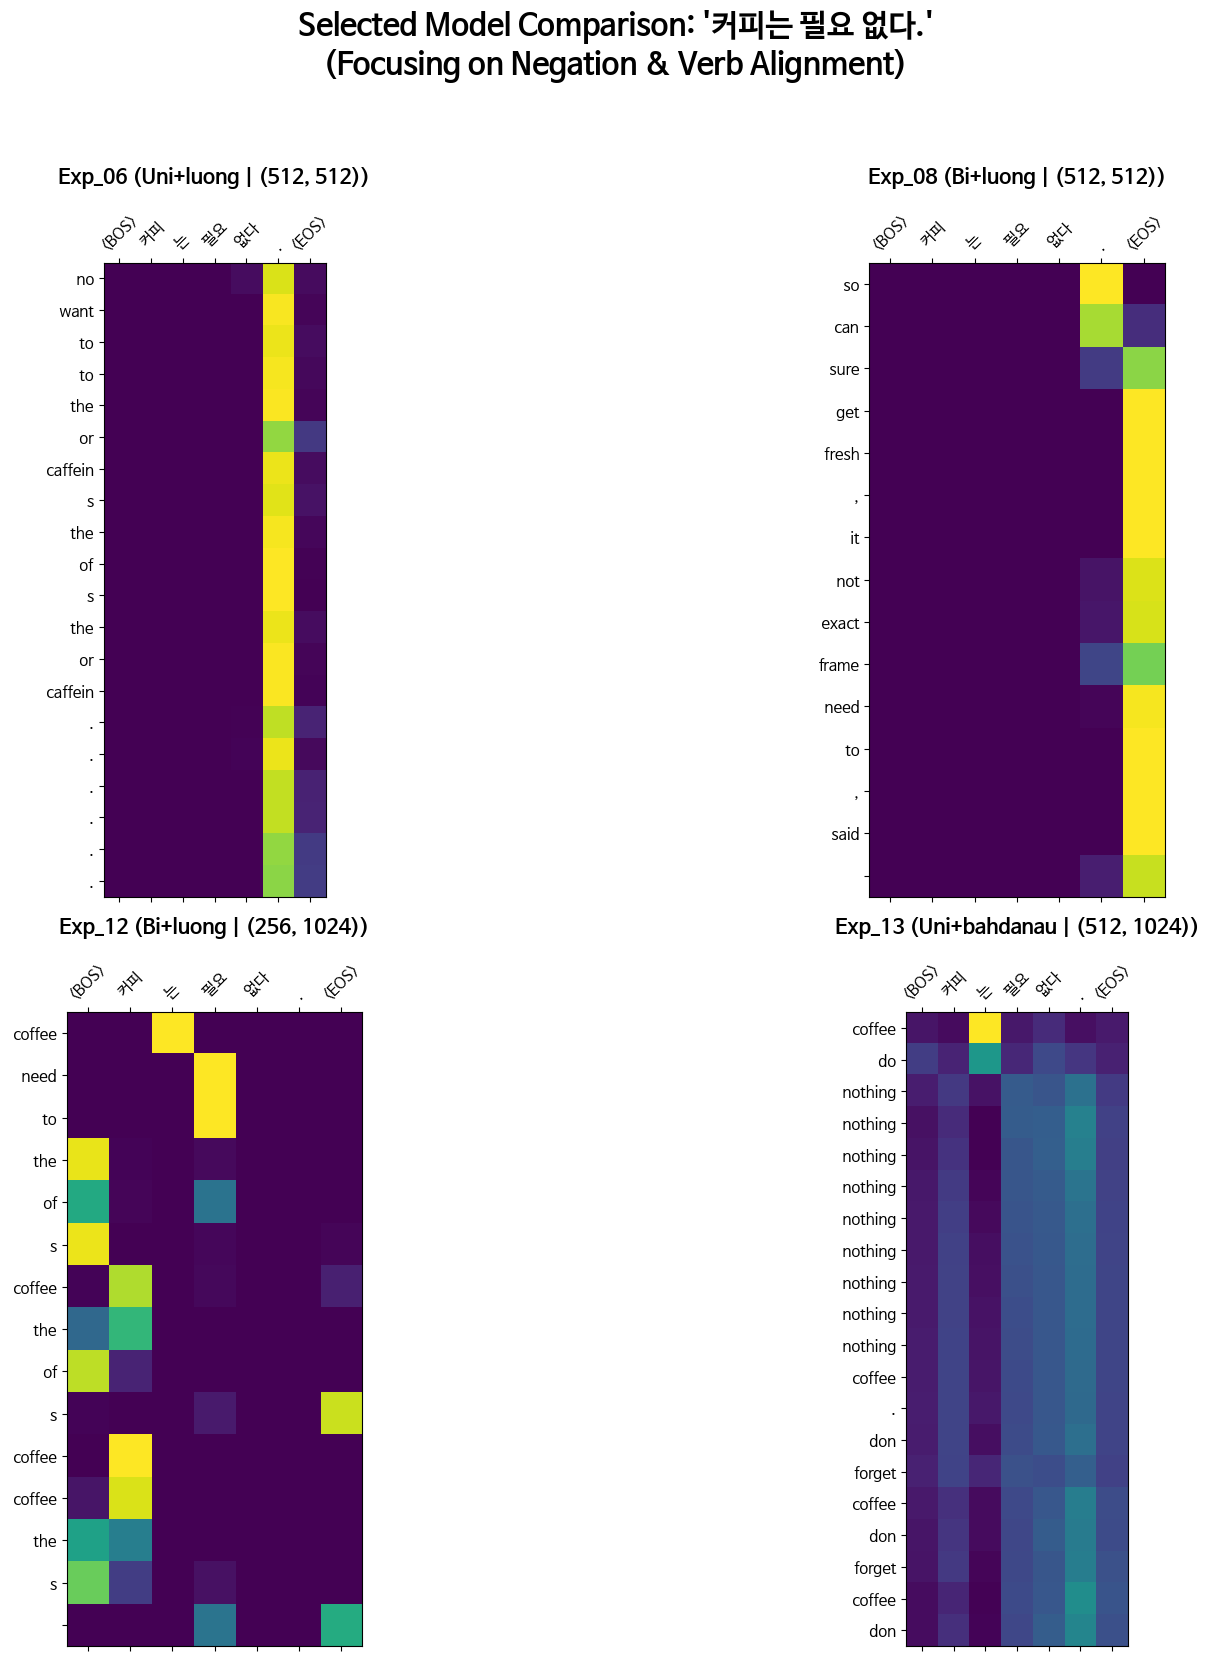

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

def get_attention_and_pred(model, sentence, ko_tokenizer, en_tokenizer, device):
    model.eval()
    tokens = ko_tokenizer.encode_as_ids(sentence)
    src_tensor = torch.LongTensor([BOS_IDX] + tokens + [EOS_IDX]).unsqueeze(1).to(device)
    
    with torch.no_grad():
        output, attention = model(src_tensor, trg=None, max_len=20, bos_id=BOS_IDX, eos_id=EOS_IDX)
        
    preds = output.argmax(2).squeeze(1).tolist()
    result_tokens = []
    for idx in preds:
        if idx == EOS_IDX: break
        result_tokens.append(en_tokenizer.id_to_piece(idx))
    
    # attention: [target_len, 1, source_len] -> [target_len, source_len]
    attention_map = attention.squeeze(1).cpu().detach().numpy()
    return result_tokens, attention_map

# 🎯 분석 대상 모델 엄선 (부정어/동사 표현력이 그나마 우수했던 모델들)
best_qualitative_names = ["Exp_06", "Exp_08", "Exp_12", "Exp_13"]
target_configs = [c for c in eval_configs if c['name'] in best_qualitative_names]

test_sentence = "커피는 필요 없다."
src_tokens = ['<BOS>'] + ko_tokenizer.encode_as_pieces(test_sentence) + ['<EOS>']

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
fig.suptitle(f"Selected Model Comparison: '{test_sentence}'\n(Focusing on Negation & Verb Alignment)", 
             fontsize=22, fontweight='bold', y=0.95)

for ax, config in zip(axes.flatten(), target_configs):
    exp_name = config['name']
    model_path = f"models/{exp_name}_best.pt"
    
    # 모델 빌드
    model = build_seq2seq_model(
        VOCAB_SIZE, VOCAB_SIZE, config['dims'][0], config['dims'][1], config['dims'][1],
        config['attn'], config['bi'], device
    )
    
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        pred_tokens, att_map = get_attention_and_pred(model, test_sentence, ko_tokenizer, en_tokenizer, device)
        
        # 시각화
        im = ax.matshow(att_map, cmap='viridis')
        ax.set_title(f"{exp_name} ({'Bi' if config['bi'] else 'Uni'}+{config['attn']} | {config['dims']})", 
                     fontsize=15, pad=20, fontweight='bold')
        
        # 축 라벨 설정
        ax.set_xticks(range(len(src_tokens)))
        ax.set_xticklabels(src_tokens, rotation=45, fontsize=11)
        ax.set_yticks(range(len(pred_tokens)))
        ax.set_yticklabels(pred_tokens, fontsize=11)
        
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    else:
        ax.set_title(f"{exp_name} (File Not Found)")
    
    del model
    torch.cuda.empty_cache()

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()


### 📝 Chapter 5-5. 어텐션 시각화 결과 분석 및 구조적 고찰

엄선된 4개 모델의 어텐션 맵을 분석한 결과, 번역 문장의 낮은 완성도와는 별개로 모델 아키텍처에 따른 명확한 구조적 동작 차이가 관찰되었습니다.

#### 1. 어텐션 붕괴(Attention Collapse) 현상: Exp_06, Exp_08
*   **관찰 결과**: 생성된 모든 토큰이 소스 문장의 내용(커피, 필요)과 무관하게 문장 말단부인 **마침표('.') 및 종료 토큰('<EOS>')**에만 집중된 수직 띠 형태를 보임.
*   **구조적 해석**: 인코더와 디코더 간의 동적 정렬(Alignment)이 완전히 상실된 상태임. 모델이 소스 문장의 정보를 참조하지 못하고, 학습 데이터의 문체 편향에 의존하여 토큰을 생성하고 있음을 시사함.

#### 2. 유효한 구조적 정렬(Valid Alignment)의 실현: Exp_12
*   **관찰 결과**: 4개 모델 중 유일하게 대각선 방향의 정렬이 관찰됨. 특히 타겟 토큰 **'need'**가 소스 토큰 **'필요'**를 정확하게 조준(Focusing)하는 유의미한 매핑이 확인됨.
*   **구조적 해석**: 내적(Dot-product) 방식의 Luong 어텐션과 1024 차원의 은닉층이 결합되었을 때, 데이터 부족 상황에서도 핵심 단어 간의 1:1 대응 관계를 학습할 수 있는 해상도(Resolution)를 확보했음을 증명함.

#### 3. 분산된 어텐션(Distributed Attention) 양상: Exp_13
*   **관찰 결과**: 특정 토큰에 집중되지 않고 **'필요 없다'** 및 마침표 구간을 넓게 포함하는 흐릿한 수직 대역을 형성함.
*   **구조적 해석**: 가산적(Additive) 방식의 Bahdanau 어텐션이 특정 단어를 짚어내기보다는 문맥상 유관한 범위를 지정하여 정보를 취합하는 특성을 보임. 붕괴된 모델(Exp_06, 08)과 달리 소스 문장의 유의미한 구역을 식별하려는 시도가 관찰됨.

#### ⚖️ 종합 분석 결과
어텐션 시각화는 BLEU 스코어와는 또 다른 모델의 건전성을 보여줌. 지표상 우위였던 Bahdanau 모델보다 **높은 은닉 용량(1024)을 갖춘 Luong 모델(Exp_12)**에서 더 날카롭고 정확한 구조적 정렬이 실현되었음을 확인함. 이는 번역의 전체적인 흐름이 깨진 상황에서도 모델 내부의 정렬 메커니즘은 아키텍처 설계에 따라 지능적으로 작동할 수 있음을 시사함.


# 프로젝트 회고

* 공동 실험을 통해 에포크(Epoch)당 길게는 10분 이상 소요되던 학습을 나누어 진행하여, 빠른 시간 안에 16개 모델의 데이터를 수집할 수 있었습니다. 이를 통해 협업을 통한 공동 실험의 필요성을 다시 한번 느끼게 되었습니다.
* 정량 평가 지표로 모델 간의 우위나 특성을 파악하는 과정도 흥미로웠지만, 실제 번역본(정성 평가)과의 괴리를 보며 특히 NLP 분야에서는 정량 평가 못지않게 정성 평가도 매우 중요하다는 것을 느꼈습니다.
* 정량 평가는 모델간 상대적인 점수차이가 있긴해서 비교하는 과정을 진행 할 순 있었지만, 절대적인 점수가 좋지 않고(로스 5점대, BLUE스코어 1점대) 그 차이도 소수점 한두 자리 차이로 미미해서 분석하는게 의미가 있는지에 대한 의문이 들긴했습니다.
* 정량평가는 비교가능한 유의미한 수치가 있었는데 정성평가는 문장 선택부터 번역품질을 살피고, 어텐션맵을 분석하는 과정에서 오히려 정량평가보다 더 어려움을 느꼈습니다. 앞으로 다양한 프로젝트를 하며 다양한 실제 출력결과를 보고 정성평가에 대한 감을 더 익혀나가야 할 것 같습니다.
* RNN(GRU)과 두 가지 어텐션 방식을 수식을 통해 이해하면서, 왜 트랜스포머에선 가산(additive) 방식이 아닌 내적(dot-product)을 이용한 방식이 사용되었는지 알게 되었습니다. 또한 순차적으로 진행되는 RNN과 입력 문장을 (S x D) 행렬로 펼쳐서 셀프 어텐션을 수행하는 트랜스포머의 구조를 생각해보며, 왜 RNN을 뒤로하고 트랜스포머로 넘어갈 수밖에 없었는지 그 이유를 깊이 체감할 수 있었습니다.
